In [1]:
# ============================================================
# CELL 1: Install & Imports
# ============================================================
!pip install -q ultralytics
!pip install transformers timm umap-learn easyocr -q

import os, json, cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import ViTModel
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as _fm

# ── CJK font fix: prevents "Glyph missing from DejaVu Sans" warnings ──
# Try known CJK font families available in Kaggle/Colab environments.
_CJK_CANDIDATES = [
    'Noto Sans CJK SC', 'Noto Sans CJK JP', 'WenQuanYi Micro Hei',
    'WenQuanYi Zen Hei', 'AR PL UMing CN', 'SimHei', 'SimSun',
]
_cjk_found = next(
    (f.name for f in _fm.fontManager.ttflist
     if any(c.lower() in f.name.lower() for c in _CJK_CANDIDATES)),
    None
)
if _cjk_found:
    plt.rcParams['font.family'] = ['DejaVu Sans', _cjk_found]
else:
    # Silently attempt install (Kaggle/Colab have network access)
    try:
        import subprocess, warnings
        subprocess.run(
            ['apt-get', 'install', '-y', '-q', 'fonts-noto-cjk'],
            capture_output=True, check=False
        )
        _fm._load_fontmanager(try_read_cache=False)
    except Exception:
        pass   # Non-fatal — Chinese labels may show boxes but code runs

try:
    import umap
    HAS_UMAP = True
except ImportError:
    from sklearn.manifold import TSNE
    HAS_UMAP = False

from sklearn.metrics.pairwise import cosine_similarity

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_ROOT = '/kaggle/input/datasets/diyer22/retail-product-checkout-dataset'
WORK_ROOT = '/kaggle/working'
CROP_DIR  = f'{WORK_ROOT}/crops'

# ── Tunable hyperparameters ─────────────────────────────────
PATCH_SIZE       = 16
IMG_SIZE         = 224
EMBED_DIM        = 128
TEMPERATURE      = 0.07
YOLO_CONF_MIN    = 0.30   # lowered: catches more crops, OCR/fallback handles edge cases
CROP_MIN_PX      = 24     # lowered: allow smaller products
ASPECT_MIN       = 0.15
ASPECT_MAX       = 6.00
# FIX: SIM_THRESHOLD set to 0 — we NEVER return Unknown; lowest-sim match is used
# OCR fallback fires only when ViT sim < OCR_FALLBACK_THRESHOLD for extra safety
SIM_THRESHOLD        = 0.0   # disabled — always return best match
OCR_FALLBACK_SIM     = 0.40  # below this, try OCR before accepting ViT result
TTA_ENABLED      = True
USE_PATCH_TOKENS = True

# ── Balanced sampler config ──────────────────────────────────
# FIX: use 8 classes × 8 samples = 64 per batch for SupCon
SAMPLES_PER_CLASS = 8
CLASSES_PER_BATCH = 8
BATCH_SIZE        = SAMPLES_PER_CLASS * CLASSES_PER_BATCH  # = 64

print(f'Device: {DEVICE}')
print(f'Batch size: {BATCH_SIZE} ({CLASSES_PER_BATCH} classes × {SAMPLES_PER_CLASS} samples)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.3 MB/s eta 0:00:00


2026-04-12 12:30:51.097240: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775997051.325617      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775997051.392389      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775997051.937474      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775997051.937517      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775997051.937520      23 computation_placer.cc:177] computation placer alr

Device: cuda
Batch size: 64 (8 classes × 8 samples)


In [2]:
# ============================================================
# CELL 2: Load metadata + build sku_lookup EARLY
# FIX: sku_lookup built here so Cell 8 gallery can use it correctly
# FIX: SKU_NAME_MAP — complete Chinese→English full product name translation
#      for all 200 RPC SKUs (brand + flavor + size).
# ============================================================
with open(f'{DATA_ROOT}/instances_train2019.json', 'rb') as f:
    train_data = json.load(f)

sku_df   = pd.DataFrame(train_data['__raw_Chinese_name_df'])
anns_df  = pd.DataFrame(train_data['annotations'])
imgs_df  = pd.DataFrame(train_data['images'])
img_dict = imgs_df.set_index('id')['file_name'].to_dict()

cat_ids      = sorted(sku_df['category_id'].unique().tolist())
cat_to_label = {c: i for i, c in enumerate(cat_ids)}
label_to_cat = {i: c for c, i in cat_to_label.items()}
NUM_CLASSES  = len(cat_ids)

print(f'Unique SKUs (classes): {NUM_CLASSES}')

# ── COMPLETE SKU_NAME_MAP: Chinese name → Full English product name ──────────
# Every one of the 200 RPC dataset SKUs is mapped to a descriptive English name.
# Format: "Brand Product Flavor/Variant Size"
SKU_NAME_MAP = {
    # ── Puffed Food (puffed_food) ─────────────────────────────────────────
    '上好佳荷兰豆55g':        'Oishi Holland Pea Crisps 55g',
    '菜园小饼80g':            'Caiyuan Garden Small Cookies 80g',
    '上好佳鲜虾片40g':        'Oishi Prawn Crackers Original 40g',
    '上好佳蟹味逸族40g':      'Oishi Crab Flavor Crisps 40g',
    '妙脆角魔力炭烧味65g':    'Doritos Magic Charcoal Grilled Flavor 65g',
    '盼盼烧烤牛排味块105g':   'Panpan BBQ Steak Flavor Puffs 105g',
    '上好佳鲜虾条40g':        'Oishi Prawn Sticks Original 40g',
    '上好佳洋葱圈40g':        'Oishi Onion Rings 40g',
    '上好佳日式鱼果海苔味50g':'Oishi Japanese Fish Puffs Seaweed Flavor 50g',
    '奇多日式牛排味90g':      'Cheetos Japanese Steak Flavor 90g',
    '奇多美式火鸡味90g':      'Cheetos American Turkey Flavor 90g',
    '上好佳粟米条草莓味40g':  'Oishi Corn Sticks Strawberry Flavor 40g',
    # ── Dried Fruit (dried_fruit) ─────────────────────────────────────────
    '甘源蟹黄味瓜子仁75g':    'Ganyuan Crab Roe Flavor Sunflower Seed Kernels 75g',
    '惠宜开心果140g':         'Huiyi Roasted Pistachio Nuts 140g',
    '惠宜咸味花生350g':       'Huiyi Salted Roasted Peanuts 350g',
    '惠宜腰果160g':           'Huiyi Cashew Nuts 160g',
    '惠宜枸杞100g':           'Huiyi Wolfberry Goji Berries 100g',
    '惠宜地瓜干228g':         'Huiyi Dried Sweet Potato Strips 228g',
    '惠宜泰国芒果干80g':      'Huiyi Thailand Dried Mango Slices 80g',
    '惠宜黄桃果干75g':        'Huiyi Dried Yellow Peach 75g',
    '惠宜柠檬片65g':          'Huiyi Dried Lemon Slices 65g',
    # ── Dried Food (dried_food) ──────────────────────────────────────────
    '新疆和田滩枣454g':       'Xinjiang Hetian Dried Red Dates 454g',
    '惠宜香菇100g':           'Huiyi Dried Shiitake Mushrooms 100g',
    '惠宜桂圆干500g':         'Huiyi Dried Longan Fruit 500g',
    '惠宜茶树菇200g':         'Huiyi Dried Tea Tree Mushrooms 200g',
    '豪雄单片黑木耳150g':     'Haoxiong Single-Slice Black Wood Ear Fungus 150g',
    '惠宜煮花生454g':         'Huiyi Boiled Peanuts in Shell 454g',
    '惠宜黄花菜100g':         'Huiyi Dried Day Lily (Daylily) 100g',
    '洽洽凉茶瓜子150g':       'Qiaqia Herbal Tea Flavor Sunflower Seeds 150g',
    '洽洽奶香味瓜子150g':     'Qiaqia Milky Flavor Sunflower Seeds 150g',
    # ── Instant Drink (instant_drink) ────────────────────────────────────
    '车仔茶包绿茶50g':        'Che Zai Green Tea Bags 50g',
    '车仔茶包红茶50g':        'Che Zai Black Tea Bags 50g',
    '优乐美香芋味80g':        'Youlemei Taro Milk Tea Powder 80g',
    '优乐美红豆奶茶65g':      'Youlemei Red Bean Milk Tea Powder 65g',
    '欢泥冲调土豆粥25g':      'Huanni Instant Potato Congee Powder 25g',
    '江中猴姑早餐米稀40g':    'Jiangzhong Monkey Head Mushroom Breakfast Rice Porridge 40g',
    '永和豆浆甜豆浆粉210g':   'Yonghe Soy Milk Sweet Soybean Milk Powder 210g',
    '立顿柠檬风味茶180g':     'Lipton Lemon Flavor Tea Bags 180g',
    '桂格多种莓果麦片40g':    'Quaker Mixed Berry Oatmeal 40g',
    '荣怡谷麦加黑米味30g':    'Rongyi Grain Plus Black Rice Flavor Cereal 30g',
    '荣怡谷麦加红豆味30g':    'Rongyi Grain Plus Red Bean Flavor Cereal 30g',
    # ── Instant Noodles (instant_noodles) ───────────────────────────────
    '今野香辣牛肉面112g':     'Jinye Spicy Beef Instant Noodles 112g',
    '今野老坛酸菜牛肉面118g': 'Jinye Old Jar Pickled Cabbage Beef Instant Noodles 118g',
    '今野红烧牛肉面114g':     'Jinye Braised Beef Instant Noodles 114g',
    '合味道海鲜风味84g':      'Cup Noodles Seafood Flavor 84g',
    '康师傅白胡椒肉骨面76g':  'Master Kong White Pepper Pork Rib Instant Noodles 76g',
    '康师傅香辣牛肉面105g':   'Master Kong Spicy Beef Instant Noodles 105g',
    '康师傅香辣蒜味排骨面108g':'Master Kong Spicy Garlic Spare Rib Instant Noodles 108g',
    '康师傅藤椒牛肉面82g':    'Master Kong Sichuan Pepper Beef Instant Noodles 82g',
    '华丰鸡肉三鲜伊面87g':    'Huafeng Chicken Triple Delight Yi Noodles 87g',
    '康师傅黑胡椒牛排面104g': 'Master Kong Black Pepper Steak Instant Noodles 104g',
    '五谷道场红烧牛肉面100g': 'Wugu Daochang Braised Beef Non-Fried Noodles 100g',
    '康师傅老坛酸菜牛肉面114g':'Master Kong Old Jar Pickled Cabbage Beef Noodles 114g',
    # ── Dessert / Biscuits (dessert) ─────────────────────────────────────
    'Aji泡芙饼干芒果菠萝味60g':'Aji Puff Biscuits Mango Pineapple Flavor 60g',
    '庆联蓝莓味夹心饼63g':    'Qinglian Blueberry Cream Sandwich Biscuits 63g',
    '庆联凤梨味夹心饼63g':    'Qinglian Pineapple Cream Sandwich Biscuits 63g',
    '庆联草莓味夹心饼63g':    'Qinglian Strawberry Cream Sandwich Biscuits 63g',
    '嘉顿威化饼干草莓味50g':  'Garden Strawberry Wafer Biscuits 50g',
    '嘉顿威化饼干柠檬味50g':  'Garden Lemon Wafer Biscuits 50g',
    '爱时乐香草牛奶味50g':    'Aishile Vanilla Milk Flavor Wafer Rolls 50g',
    '爱时乐巧克力味50g':      'Aishile Chocolate Flavor Wafer Rolls 50g',
    '百力滋海苔味60g':        'Pocky Seaweed Flavor Biscuit Sticks 60g',
    '百力滋草莓牛奶味45g':    'Pocky Strawberry Milk Flavor Biscuit Sticks 45g',
    '雀巢脆脆鲨80g':          'Nestle Kit Kat Crispy Shark Chocolate Wafer 80g',
    '纳宝帝巧克力味威化58g':  'Nabati Chocolate Flavor Wafer Biscuits 58g',
    '桂力地中海风味面包条50g': 'Guili Mediterranean Flavor Bread Sticks 50g',
    '康师傅妙芙巧克力味48g':  'Master Kong Marvellous Choco Cupcake 48g',
    '爱乡亲唱片面包90g':      'Aixiangqin Record-Shaped Soft Bread 90g',
    '达利园派草莓味单个装*':   'Dali Garden Strawberry Swiss Roll Cake Single Pack',
    'mini奥利奥55g':          'Oreo Mini Chocolate Sandwich Cookies 55g',
    # ── Drinks (drink) ───────────────────────────────────────────────────
    '农夫山泉矿泉水550ml':    'Nongfu Spring Natural Mineral Water 550ml',
    '怡宝矿泉水555ml':        'C est Bon Purified Drinking Water 555ml',
    '可口可乐零度500ml':      'Coca-Cola Zero Sugar 500ml',
    '可口可乐500ml':          'Coca-Cola Classic 500ml',
    '百事可乐600ml':          'Pepsi Cola 600ml',
    '芬达苹果味500ml':        'Fanta Apple Flavor Sparkling Drink 500ml',
    '芬达橙味500ml':          'Fanta Orange Flavor Sparkling Drink 500ml',
    '雪碧500ml':              'Sprite Lemon-Lime Sparkling Drink 500ml',
    '百事可乐330ml':          'Pepsi Cola 330ml Can',
    '可口可乐330ml':          'Coca-Cola Classic 330ml Can',
    '王老吉310ml':            'Wanglaoji Herbal Cooling Tea 310ml',
    '茶派柚子绿茶500ml':      'Chapai Yuzu Green Tea 500ml',
    '茶派玫瑰荔枝红茶500ml':  'Chapai Rose Lychee Black Tea 500ml',
    '康师傅冰红茶250ml':      'Master Kong Iced Black Tea 250ml',
    '加多宝250ml':            'Jiaduobao Herbal Cooling Tea 250ml',
    # ── Alcohol (alcohol) ────────────────────────────────────────────────
    '喜力啤酒500ml':          'Heineken Lager Beer 500ml Can',
    '百威啤酒600ml':          'Budweiser American Lager Beer 600ml',
    'RIO果酒水蜜桃味275ml':   'RIO Cocktail White Peach & Vodka 275ml',
    'RIO果酒蓝玫瑰威士忌味275ml':'RIO Cocktail Blue Rose & Whisky 275ml',
    '牛栏山二锅头100ml':      'Niulanshan Erguotou Chinese Baijiu Spirits 100ml',
    '哈尔滨啤酒330ml':        'Harbin Beer Classic Lager 330ml Can',
    '青岛啤酒330ml':          'Tsingtao Beer Classic Lager 330ml',
    '雪花啤酒330ml':          'Snow Beer Fresh Lager 330ml Can',
    '哈尔滨啤酒500ml':        'Harbin Beer Classic Lager 500ml Can',
    'KELER啤酒500ml':         'Keler Spanish Lager Beer 500ml',
    '百威啤酒500ml':          'Budweiser American Lager Beer 500ml Can',
    # ── Milk / Dairy Drinks (milk) ───────────────────────────────────────
    'QQ星全聪奶125ml':        'QQ Star All-Round Smart Kids Milk Drink 125ml',
    'QQ星均膳奶125ml':        'QQ Star Balanced Nutrition Kids Milk Drink 125ml',
    '娃哈哈AD钙奶220g':       'Wahaha AD Calcium Milk Drink 220g',
    '活力宝动力源105ml':       'Huilibao Power Source Childrens Milk Drink 105ml',
    '旺仔牛奶复原乳250ml':    'Want Want Reconstituted Whole Milk 250ml',
    '伊利纯牛奶250ml':        'Yili Pure Fresh Whole Milk 250ml',
    '维他低糖原味豆奶250ml':   'Vita Low Sugar Original Soy Milk 250ml',
    '百怡花生牛奶250ml':      'Baiyi Peanut Milk Drink 250ml',
    '惠宜原味豆奶250ml':      'Huiyi Original Flavor Soy Milk 250ml',
    '伊利优酸乳250ml':        'Yili Yousuanru Yogurt Drink 250ml',
    '伊利早餐奶250ml':        'Yili Breakfast Milk 250ml',
    # ── Canned Food (canned_food) ────────────────────────────────────────
    '达利园桂圆莲子360g':     'Dali Garden Longan & Lotus Seed Canned Dessert 360g',
    '银鹭冰糖百合银耳280g':   'Yinlu Rock Sugar Lily & White Fungus Canned Dessert 280g',
    '喜多多什锦椰果567g':     'XiDuoDuo Assorted Coconut Jelly Mixed Canned 567g',
    '都乐菠萝块567g':         'Dole Pineapple Chunks in Juice 567g',
    '都乐菠萝块234g':         'Dole Pineapple Chunks in Juice 234g',
    '银鹭薏仁红豆粥280g':     'Yinlu Barley & Red Bean Congee Canned 280g',
    '银鹭莲子玉米粥280g':     'Yinlu Lotus Seed & Corn Congee Canned 280g',
    '银鹭紫薯紫米粥280g':     'Yinlu Purple Sweet Potato & Black Rice Congee 280g',
    '银鹭椰奶燕麦粥280g':     'Yinlu Coconut Milk & Oat Congee Canned 280g',
    '银鹭黑糖桂圆280g':       'Yinlu Brown Sugar & Longan Canned Dessert 280g',
    '梅林午餐肉340g':         'Maling Luncheon Meat Canned Pork 340g',
    '珠江桥牌豆豉鱼150g':     'Pearl River Bridge Black Bean Sauce Fish Canned 150g',
    '古龙原味黄花鱼120g':     'Gulong Original Flavor Yellow Croaker Fish Canned 120g',
    '雄鸡标椰浆140ml':        'Rooster Brand Coconut Cream 140ml',
    # ── Chocolate (chocolate) ────────────────────────────────────────────
    '德芙芒果酸奶巧克力42g':  'Dove Mango Yogurt Chocolate Bar 42g',
    '德芙摩卡巴旦木巧克力43g':'Dove Mocha Almond Chocolate Bar 43g',
    '德芙百香果白巧克力42g':  'Dove Passion Fruit White Chocolate Bar 42g',
    'MM花生牛奶巧克力豆40g':  "M&Ms Peanut Milk Chocolate Candies 40g",
    'MM牛奶巧克力豆40g':      "M&Ms Milk Chocolate Candies 40g",
    '好时牛奶巧克力40g':      "Hershey's Milk Chocolate Bar 40g",
    '好时曲奇奶香白巧克力40g':"Hersheys Cookies & Cream White Chocolate Bar 40g",
    '脆香米海苔白巧克力24g':  'Crispy Rice Seaweed White Chocolate Snack Bar 24g',
    '脆香米奶香白巧克力24g':  'Crispy Rice Milky White Chocolate Snack Bar 24g',
    '士力架花生夹心巧克力51g':'Snickers Peanut Caramel Chocolate Bar 51g',
    '士力架燕麦花生夹心巧克力40g':'Snickers Oat & Peanut Chocolate Bar 40g',
    '士力架辣花生夹心巧克力40g':'Snickers Spicy Peanut Chocolate Bar 40g',
    # ── Gum (gum) ────────────────────────────────────────────────────────
    '炫迈果味浪薄荷味37g':    'Stride Fruit Wave Peppermint Chewing Gum 37g',
    '炫迈果味浪柠檬味37g':    'Stride Fruit Wave Lemon Chewing Gum 37g',
    '炫迈薄荷味21g':          'Stride Spearmint Chewing Gum 21g',
    '炫迈葡萄味21g':          'Stride Grape Flavor Chewing Gum 21g',
    '炫迈西瓜味21g':          'Stride Watermelon Flavor Chewing Gum 21g',
    '炫迈葡萄味50g':          'Stride Grape Flavor Chewing Gum 50g',
    '绿箭无糖薄荷糖茉莉花茶味34g':'Extra Sugar-Free Jasmine Green Tea Mint Candy 34g',
    '绿箭5片装15g':           'Extra Spearmint Chewing Gum 5-Piece Pack 15g',
    # ── Candy (candy) ────────────────────────────────────────────────────
    '比巴卜棉花泡泡糖可乐味11g':'Big Babol Cola Flavor Cotton Bubble Gum 11g',
    '比巴卜棉花泡泡堂葡萄味11g':'Big Babol Grape Flavor Cotton Bubble Gum 11g',
    '星爆缤纷原果味25g':      'Starburst Original Fruit Chews Assorted 25g',
    '阿尔卑斯焦香牛奶味硬糖45g':'Alps Caramel Milk Hard Candy 45g',
    '阿尔卑斯牛奶软糖黄桃酸奶味47g':'Alps Yellow Peach Yogurt Soft Milk Candy 47g',
    '阿尔卑斯牛奶软糖蓝莓酸奶味47g':'Alps Blueberry Yogurt Soft Milk Candy 47g',
    '王老吉润喉糖28g':        'Wanglaoji Herbal Throat Lozenges 28g',
    '伊利牛奶片蓝莓味32g':    'Yili Blueberry Flavor Milk Tablet Candy 32g',
    '熊博士口嚼糖草莓牛奶味52g':'Dr. Bear Strawberry Milk Flavor Chew Candy 52g',
    '彩虹糖原果味45g':        'Skittles Original Fruit Flavor Chewy Candy 45g',
    # ── Seasoning (seasoner) ─────────────────────────────────────────────
    '宝鼎天鱼陈酿米醋245ml':  'Baoding Tianyu Aged Rice Vinegar 245ml',
    '恒顺香醋340ml':          'Hengshun Zhenjiang Aromatic Black Vinegar 340ml',
    '太太乐鸡精200g':         'Taitaile Chicken Essence Seasoning Powder 200g',
    '家乐香菇鸡茸汤料41g':    'Knorr Shiitake Mushroom & Chicken Broth Seasoning 41g',
    '惠宜辣椒粉15g':          'Huiyi Chili Powder Seasoning 15g',
    '惠宜生姜粉15g':          'Huiyi Ginger Powder Seasoning 15g',
    '味好美椒盐20g':          'McCormick Salt & Pepper Seasoning 20g',
    '海星加碘精制盐400g':     'Haixing Iodized Refined Table Salt 400g',
    '恒顺料酒500ml':          'Hengshun Shaoxing Cooking Wine 500ml',
    '东古味极鲜酱油150ml':    'Donggu Weijixian Superior Soy Sauce 150ml',
    '东古一品鲜酱油150ml':    'Donggu Yipinxian Premium Soy Sauce 150ml',
    '欣和六月鲜酱油160ml':    'Xin He June Fresh Light Soy Sauce 160ml',
    # ── Personal Hygiene (personal_hygiene) ──────────────────────────────
    '李施德林零度漱口水80ml':  'Listerine Zero Alcohol Mouthwash 80ml',
    '舒肤佳纯白清香沐浴露100ml':'Safeguard Pure White Fresh Scent Body Wash 100ml',
    '美涛定型啫喱水60ml':      'Meitao Hair Styling Gel Water 60ml',
    '清扬男士洗发露活力运动薄荷型50ml':'Clear Men Active Sport Menthol Shampoo 50ml',
    '蓝月亮风清白兰洗衣液80g': 'Blue Moon Breeze Fresh Laundry Liquid 80g',
    '高露洁亮白小苏打180g':   'Colgate Whitening Baking Soda Toothpaste 180g',
    '高露洁冰爽180g':          'Colgate Ice Cool Mint Toothpaste 180g',
    '舒亮皓齿白80g':           'Shuoliang Bright White Toothpaste 80g',
    '云南白药牙膏45g':         'Yunnan Baiyao Herbal Toothpaste 45g',
    '舒克宝贝儿童牙刷':        'Shu Ke Baby Childrens Toothbrush',
    # ── Tissue / Paper (tissue) ──────────────────────────────────────────
    '清风原木纯品金装100x3':   'Qingfeng Original Wood Pure Gold Edition Tissue 100 Sheets x3',
    '洁柔face150x3':          'Jierou Face Care Facial Tissue 150 Sheets x3',
    '斑布100x3':              'Bambook Bamboo Fiber Tissue 100 Sheets x3',
    '维达婴儿150x3':          'Vinda Baby Gentle Tissue 150 Sheets x3',
    '相印小黄人150x3':        'Xiang Yin Minions Edition Tissue 150 Sheets x3',
    '清风原木纯品黑耀150x3':  'Qingfeng Original Wood Pure Black Diamond Tissue 150 Sheets x3',
    '洁云绒触感130x3':        'Jieyun Velvet Touch Tissue 130 Sheets x3',
    '舒洁萌印花120x2':        'Scotties Cute Print Tissue 120 Sheets x2',
    '相印红悦130x3':          'Xiang Yin Red Joy Tissue 130 Sheets x3',
    '得宝苹果木味90x4':       'Tempo Apple Wood Scent Tissue 90 Sheets x4',
    '清风新韧纯品130x3':      'Qingfeng New Strong Pure Tissue 130 Sheets x3',
    '金鱼竹浆绿135x3':        'Goldfish Bamboo Pulp Green Tissue 135 Sheets x3',
    '清风原木纯品150x2':      'Qingfeng Original Wood Pure Tissue 150 Sheets x2',
    '洁柔face130x3':          'Jierou Face Care Facial Tissue 130 Sheets x3',
    '维达立体美110x3':        'Vinda 3D Texture Embossed Tissue 110 Sheets x3',
    '洁柔CS单包*':            'Jierou CS Single Pack Pocket Tissue',
    '相印小黄人单包*':        'Xiang Yin Minions Edition Single Pack Pocket Tissue',
    '清风原色单包*':          'Qingfeng Natural Color Single Pack Pocket Tissue',
    '相印茶语单包*':          'Xiang Yin Tea Mood Single Pack Pocket Tissue',
    '清风质感纯品单包*':      'Qingfeng Premium Pure Single Pack Pocket Tissue',
    # ── Stationery (stationery) ──────────────────────────────────────────
    '米奇1928笔记本':         'Mickey Mouse 1928 Notebook Notepad',
    '广博固体胶15g':          'Guangbo Solid Glue Stick 15g',
    '票据文件袋':             'Bill & Document Organizer File Bag',
    '晨光蜗牛改正带':         'Morning Glory Snail Correction Tape',
    '鸿泰液体胶50g':          'Hongtai Liquid Glue 50g',
    '马培德自粘性标签':       'Maped Self-Adhesive Label Stickers',
    '东亚记号笔':             'Dongya Permanent Marker Pen',
}

# Legacy BRAND_MAP kept for extract_brand() used in OCR engine
BRAND_MAP = {
    '百事可乐': 'Pepsi', '可口可乐': 'Coca-Cola', '雪碧': 'Sprite',
    '芬达': 'Fanta', '农夫山泉': 'Nongfu Spring', '王老吉': 'Wanglaoji',
    '加多宝': 'Jiaduobao', '怡宝': 'Yibao', '娃哈哈': 'Wahaha',
    '维他': 'Vita', '茶派': 'Chapai', '优乐美': 'Youlemei',
    '美涛': 'Meitao', '活力宝': 'Huilibao', '百怡': 'Baiyi', '荣怡': 'Rongyi',
    '喜力': 'Heineken', '百威': 'Budweiser', '青岛': 'Tsingtao',
    '雪花': 'Snow Beer', '燕京': 'Yanjing', '珠江': 'Pearl River',
    '伊利': 'Yili', '蒙牛': 'Mengniu', '光明': 'Bright Dairy',
    '三元': 'Sanyuan', '银鹭': 'Yinlu', '永和': 'Yonghe', '江中': 'Jiangzhong',
    '德芙': 'Dove', '士力架': 'Snickers', '好时': "Hershey's",
    '彩虹糖': 'Skittles', '星爆': 'Starburst', '阿尔卑斯': 'Alps',
    '熊博士': 'Dr. Bear', '炫迈': 'Stride', '绿箭': 'Extra',
    '奥利奥': 'Oreo', '百力滋': 'Pocky', '纳宝帝': 'Nabati',
    '奇多': 'Cheetos', '妙脆角': 'Doritos', '上好佳': 'Oishi',
    '旺仔': 'Want Want', '洽洽': 'Qiaqia', '脆香米': 'Crispy Rice',
    '嘉顿': 'Garden', '比巴卜': 'Big Babol', '盼盼': 'Panpan',
    '达利园': 'Dali Garden', '爱时乐': 'Aishile', '桂力': 'Guili',
    '车仔': 'Che Zai', '爱乡亲': 'Aixiangqin', '宝鼎': 'Baoding',
    '庆联': 'Qinglian', '菜园': 'Caiyuan', '鸿泰': 'Hongtai',
    '今野': 'Jinye', '五谷道场': 'Wugu Daochang',
    '康师傅': 'Master Kong', '合味道': 'Cup Noodles',
    '华丰': 'Huafeng', '雀巢': 'Nestle',
    '恒顺': 'Hengshun', '太太乐': 'Taitaile', '家乐': 'Knorr',
    '味好美': 'McCormick', '海星': 'Haixing', '东古': 'Donggu',
    '欣和': 'Xin He', '广博': 'Guangbo',
    '清风': 'Qingfeng', '洁柔': 'Jierou', '相印': 'Xiang Yin',
    '洁云': 'Jieyun', '舒洁': 'Scotties', '得宝': 'Tempo', '斑布': 'Bambook',
    '高露洁': 'Colgate', '云南白药': 'Yunnan Baiyao', '李施德林': 'Listerine',
    '蓝月亮': 'Blue Moon', '清扬': 'Clear', '舒亮': 'Shuoliang',
    '舒克': 'Shu Ke', '惠宜': 'Huiyi', '金鱼': 'Goldfish',
    '晨光': 'Morning Glory', '马培德': 'Maped', '东亚': 'Dongya', '米奇': 'Mickey',
    '立顿': 'Lipton', '桂格': 'Quaker', '甘源': 'Ganyuan',
    '喜多多': 'XiDuoDuo', '都乐': 'Dole', '梅林': 'Maling',
    '珠江桥牌': 'Pearl River Bridge', '古龙': 'Gulong', '雄鸡标': 'Rooster Brand',
    'QQ星': 'QQ Star', '舒肤佳': 'Safeguard', '维达': 'Vinda',
    '哈尔滨': 'Harbin Beer', '牛栏山': 'Niulanshan',
}

def extract_brand(chinese_name):
    """Returns full English product name from SKU_NAME_MAP, falls back to brand-only."""
    # First: try full product name lookup
    if chinese_name in SKU_NAME_MAP:
        return SKU_NAME_MAP[chinese_name]
    # Second: try brand-level match from BRAND_MAP
    for cn, en in BRAND_MAP.items():
        if cn in chinese_name:
            return en
    return chinese_name

sku_df['brand'] = sku_df['name'].apply(extract_brand)
sku_lookup = sku_df.set_index('category_id')[
    ['sku_class', 'name', 'brand', 'code']
].to_dict(orient='index')

# Audit
unmapped = sku_df[sku_df['brand'] == sku_df['name']]
if len(unmapped) > 0:
    print(f'WARNING: {len(unmapped)} SKUs still using Chinese name:')
    print(unmapped[['category_id','name','sku_class']].to_string())
else:
    print(f'All {NUM_CLASSES} SKUs fully mapped to English product names.')

print('\nSample translations:')
for cn, en in list(SKU_NAME_MAP.items())[:8]:
    print(f'  {cn:30s} → {en}')


Unique SKUs (classes): 200
All 200 SKUs fully mapped to English product names.

Sample translations:
  上好佳荷兰豆55g                      → Oishi Holland Pea Crisps 55g
  菜园小饼80g                        → Caiyuan Garden Small Cookies 80g
  上好佳鲜虾片40g                      → Oishi Prawn Crackers Original 40g
  上好佳蟹味逸族40g                     → Oishi Crab Flavor Crisps 40g
  妙脆角魔力炭烧味65g                    → Doritos Magic Charcoal Grilled Flavor 65g
  盼盼烧烤牛排味块105g                   → Panpan BBQ Steak Flavor Puffs 105g
  上好佳鲜虾条40g                      → Oishi Prawn Sticks Original 40g
  上好佳洋葱圈40g                      → Oishi Onion Rings 40g


In [3]:
# ============================================================
# CELL 3: Crop extraction
# FIX: Save crops to both train_gallery/ and val/ sub-dirs
#      so gallery never overlaps with validation.
#      train_gallery/ = 70% of crops → gallery + training
#      val/           = 30% of crops → evaluation only
# ============================================================
MAX_PER_SKU         = 80   # slightly more crops for better coverage
VAL_FRACTION        = 0.30 # 30% held out strictly for evaluation

def is_valid_crop(x, y, w, h, img_shape):
    if w < CROP_MIN_PX or h < CROP_MIN_PX:
        return False, 'too_small'
    ratio = w / max(h, 1)
    if not (ASPECT_MIN <= ratio <= ASPECT_MAX):
        return False, 'bad_aspect'
    ih, iw = img_shape[:2]
    overlap_w = min(x + w, iw) - max(x, 0)
    overlap_h = min(y + h, ih) - max(y, 0)
    if overlap_w / w < 0.7 or overlap_h / h < 0.7:
        return False, 'out_of_bounds'
    return True, 'ok'


def save_crops_split(anns, img_dict, data_split='train',
                     max_per_sku=80, val_frac=0.30):
    """
    FIX: For each SKU, saves the first (1-val_frac) crops to
    CROP_DIR/train_gallery and the remaining val_frac to
    CROP_DIR/val. This guarantees zero overlap between
    the gallery and the evaluation set.
    """
    counts, val_counts = defaultdict(int), defaultdict(int)
    skipped = 0
    rejected = defaultdict(int)

    for _, ann in tqdm(anns.iterrows(), total=len(anns),
                       desc=f'Cropping {data_split}'):
        cat_id = int(ann['category_id'])
        total_saved = counts[cat_id] + val_counts[cat_id]
        if total_saved >= max_per_sku:
            continue

        fname    = img_dict.get(ann['image_id'])
        img_path = f'{DATA_ROOT}/{data_split}2019/{fname}'
        if not os.path.exists(img_path):
            skipped += 1
            continue
        img = cv2.imread(img_path)
        if img is None:
            continue

        x, y, w, h = [int(v) for v in ann['bbox']]
        valid, reason = is_valid_crop(x, y, w, h, img.shape)
        if not valid:
            rejected[reason] += 1
            continue

        pad  = 10
        crop = img[max(0,y-pad):min(img.shape[0],y+h+pad),
                   max(0,x-pad):min(img.shape[1],x+w+pad)]
        if crop.size == 0:
            continue

        # Decide train_gallery vs val based on count ratio
        train_quota = int(max_per_sku * (1 - val_frac))
        if counts[cat_id] < train_quota:
            out_dir = f'{CROP_DIR}/train_gallery/sku_{cat_id}'
            counts[cat_id] += 1
        else:
            out_dir = f'{CROP_DIR}/val/sku_{cat_id}'
            val_counts[cat_id] += 1

        os.makedirs(out_dir, exist_ok=True)
        cv2.imwrite(f'{out_dir}/{ann["id"]}.jpg', crop)

    total_train = sum(counts.values())
    total_val   = sum(val_counts.values())
    print(f'Saved {total_train} train_gallery + {total_val} val crops')
    print(f'Skipped (missing) {skipped} | Rejected: {dict(rejected)}')
    print(f'Overlap check: {len(set(counts.keys()) & set(val_counts.keys()))} '
          f'categories in both splits (expected = all {NUM_CLASSES})')


if not os.path.exists(f'{CROP_DIR}/train_gallery'):
    save_crops_split(anns_df, img_dict, data_split='train',
                     max_per_sku=MAX_PER_SKU, val_frac=VAL_FRACTION)
else:
    # Count existing crops
    n_train = sum(len(list(p.glob('*.jpg')))
                  for p in Path(f'{CROP_DIR}/train_gallery').iterdir())
    n_val   = sum(len(list(p.glob('*.jpg')))
                  for p in Path(f'{CROP_DIR}/val').iterdir())
    print(f'Crops already exist: {n_train} train_gallery, {n_val} val')

Cropping train: 100%|██████████| 53739/53739 [08:09<00:00, 109.81it/s]

Saved 11200 train_gallery + 4800 val crops
Skipped (missing) 0 | Rejected: {'bad_aspect': 216}
Overlap check: 200 categories in both splits (expected = all 200)


In [4]:
# ============================================================
# CELL 4: Dataset  — FIX: separate Dataset objects (no shared .dataset)
# FIX: BalancedBatchSampler ensures SupCon always gets same-class pairs
# ============================================================
train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

tta_transforms = [
    transforms.Compose([transforms.ToPILImage(),
                        transforms.Resize((IMG_SIZE, IMG_SIZE)),
                        transforms.ToTensor(),
                        transforms.Normalize([0.5]*3, [0.5]*3)]),
    transforms.Compose([transforms.ToPILImage(),
                        transforms.Resize((IMG_SIZE, IMG_SIZE)),
                        transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(),
                        transforms.Normalize([0.5]*3, [0.5]*3)]),
    transforms.Compose([transforms.ToPILImage(),
                        transforms.Resize((int(IMG_SIZE*1.1), int(IMG_SIZE*1.1))),
                        transforms.CenterCrop(IMG_SIZE),
                        transforms.ToTensor(),
                        transforms.Normalize([0.5]*3, [0.5]*3)]),
    transforms.Compose([transforms.ToPILImage(),
                        transforms.Resize((IMG_SIZE, IMG_SIZE)),
                        transforms.RandomVerticalFlip(p=1.0),
                        transforms.ToTensor(),
                        transforms.Normalize([0.5]*3, [0.5]*3)]),
]


class SKUCropDataset(Dataset):
    def __init__(self, crop_root, cat_to_label, transform):
        self.samples      = []
        self.transform    = transform
        self.cat_to_label = cat_to_label
        self.label_to_indices = defaultdict(list)

        for folder in sorted(Path(crop_root).iterdir()):
            if not folder.is_dir():
                continue
            cat_id = int(folder.name.replace('sku_', ''))
            label  = cat_to_label.get(cat_id, -1)
            if label == -1:
                continue
            for img_path in folder.glob('*.jpg'):
                idx = len(self.samples)
                self.samples.append((str(img_path), label))
                self.label_to_indices[label].append(idx)

        print(f'Dataset [{crop_root}]: {len(self.samples)} samples, '
              f'{len(self.label_to_indices)} classes')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        if img is None:
            # Return a black image as fallback instead of crashing
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self.transform(img), label


# FIX: Two SEPARATE dataset objects — train_gallery and val never share .transform
train_ds = SKUCropDataset(f'{CROP_DIR}/train_gallery', cat_to_label, train_tf)
val_ds   = SKUCropDataset(f'{CROP_DIR}/val',           cat_to_label, val_tf)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')


# ── FIX: BalancedBatchSampler for SupCon ────────────────────
class BalancedBatchSampler:
    """
    FIX: Ensures each batch contains exactly
    n_classes × n_samples_per_class items, guaranteeing
    same-class pairs for SupCon loss.
    """
    def __init__(self, dataset, n_classes, n_samples):
        self.label_to_indices = {k: list(v)
                                 for k, v in dataset.label_to_indices.items()}
        self.labels  = list(self.label_to_indices.keys())
        self.n_cls   = n_classes
        self.n_samp  = n_samples
        self.n_batches = len(dataset) // (n_classes * n_samples)

    def __iter__(self):
        for _ in range(self.n_batches):
            batch = []
            chosen_classes = np.random.choice(
                self.labels,
                min(self.n_cls, len(self.labels)),
                replace=False
            )
            for cls in chosen_classes:
                indices = self.label_to_indices[cls]
                if len(indices) < self.n_samp:
                    chosen = np.random.choice(indices, self.n_samp, replace=True)
                else:
                    chosen = np.random.choice(indices, self.n_samp, replace=False)
                batch.extend(chosen.tolist())
            yield batch

    def __len__(self):
        return self.n_batches


balanced_sampler = BalancedBatchSampler(
    train_ds, n_classes=CLASSES_PER_BATCH, n_samples=SAMPLES_PER_CLASS
)

train_loader = DataLoader(
    train_ds,
    batch_sampler=balanced_sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True
)

print(f'Batches per epoch: {len(train_loader)}')
print(f'Each batch: {BATCH_SIZE} samples, {CLASSES_PER_BATCH} classes, '
      f'{SAMPLES_PER_CLASS} samples/class')

Dataset [/kaggle/working/crops/train_gallery]: 11200 samples, 200 classes
Dataset [/kaggle/working/crops/val]: 4800 samples, 200 classes
Train: 11200 | Val: 4800
Batches per epoch: 175
Each batch: 64 samples, 8 classes, 8 samples/class


In [5]:
# ============================================================
# CELL 5: ViT Model with Projection Head  (unchanged)
# ============================================================
class ViTSKUEncoder(nn.Module):
    def __init__(self, embed_dim=128, num_classes=200, use_patch_tokens=True):
        super().__init__()
        self.use_patch_tokens = use_patch_tokens
        self.vit = ViTModel.from_pretrained('WinKawaks/vit-small-patch16-224')
        hidden   = self.vit.config.hidden_size

        proj_in  = hidden * 2 if use_patch_tokens else hidden

        self.projector = nn.Sequential(
            nn.Linear(proj_in, 512),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(256, embed_dim)
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, pixel_values, return_embed=False, return_attentions=False):
        out = self.vit(
            pixel_values=pixel_values,
            output_attentions=return_attentions
        )

        cls_token    = out.last_hidden_state[:, 0, :]
        patch_tokens = out.last_hidden_state[:, 1:, :]

        if self.use_patch_tokens:
            patch_mean = patch_tokens.mean(dim=1)
            combined   = torch.cat([cls_token, patch_mean], dim=1)
        else:
            combined = cls_token

        embed  = self.projector(combined)
        embed  = F.normalize(embed, p=2, dim=1)

        if return_attentions:
            # Guard: ViTModel returns None for attentions when not configured.
            # Return empty tuple so callers can do `if attentions:` safely.
            attns = out.attentions if out.attentions is not None else ()
            return embed, attns
        if return_embed:
            return embed

        logits = self.classifier(embed)
        return embed, logits


model = ViTSKUEncoder(
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    use_patch_tokens=USE_PATCH_TOKENS
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params/1e6:.1f}M')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: WinKawaks/vit-small-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 22.4M


In [6]:
# ============================================================
# CELL 6: Supervised Contrastive Loss  (unchanged logic)
# ============================================================
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07, hard_neg_topk=None):
        super().__init__()
        self.temperature   = temperature
        self.hard_neg_topk = hard_neg_topk

    def forward(self, embeddings, labels):
        B      = embeddings.shape[0]
        device = embeddings.device

        sim       = torch.matmul(embeddings, embeddings.T) / self.temperature
        mask_self = ~torch.eye(B, dtype=torch.bool, device=device)
        labels_   = labels.unsqueeze(1)
        mask_pos  = (labels_ == labels_.T) & mask_self

        has_pos = mask_pos.sum(1) > 0
        if has_pos.sum() == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)

        sim        = sim[has_pos]
        mask_pos   = mask_pos[has_pos]
        mask_self_f = mask_self[has_pos]

        # Numerical stability: subtract row-max before exp (logsumexp trick).
        # Mathematically equivalent to the original — gradients are unchanged.
        # Without this, exp(sim/T) with T=0.07 overflows float32 (sim≈1 → e^14).
        sim_stable = sim - sim.max(dim=1, keepdim=True).values.detach()
        exp_sim    = torch.exp(sim_stable)
        log_denom  = torch.log((exp_sim * mask_self_f).sum(dim=1, keepdim=True) + 1e-8)
        loss       = -(sim_stable - log_denom) * mask_pos
        loss       = loss.sum(1) / mask_pos.sum(1).clamp(min=1)
        return loss.mean()


class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5, temperature=0.07):
        super().__init__()
        self.supcon = SupConLoss(temperature)
        self.ce     = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.alpha  = alpha

    def forward(self, embeddings, logits, labels):
        loss_sc = self.supcon(embeddings, labels)
        loss_ce = self.ce(logits, labels)
        total   = self.alpha * loss_sc + (1 - self.alpha) * loss_ce
        return total, loss_sc.item(), loss_ce.item()


criterion = CombinedLoss(alpha=0.5, temperature=TEMPERATURE)
print('Loss: SupCon (balanced batches) + CrossEntropy with label smoothing')

Loss: SupCon (balanced batches) + CrossEntropy with label smoothing


In [7]:
# ============================================================
# CELL 7: Training loop
# FIX: val_loader now uses separate val_ds (no overlap with train)
# FIX: train_loader uses BalancedBatchSampler (SupCon gets real pairs)
# ============================================================
EPOCHS = 30
LR     = 2e-5

optimizer = AdamW([
    {'params': model.vit.parameters(),        'lr': LR},
    {'params': model.projector.parameters(),  'lr': LR * 10},
    {'params': model.classifier.parameters(), 'lr': LR * 10},
], weight_decay=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)

best_val_acc = 0.0
history = {'train_loss': [], 'val_acc': [], 'sc_loss': [], 'ce_loss': []}

for epoch in range(EPOCHS):
    model.train()
    total_loss = total_sc = total_ce = 0
    correct = total = 0

    for imgs, labels in tqdm(train_loader,
                              desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        embeds, logits = model(imgs)
        loss, sc, ce   = criterion(embeds, logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_sc   += sc
        total_ce   += ce
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)

    scheduler.step()
    train_acc = correct / total

    # FIX: evaluate on truly separate val_ds
    model.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            _, logits    = model(imgs)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += len(labels)
    val_acc = val_correct / val_total

    n = len(train_loader)
    print(f'Epoch {epoch+1:02d}/{EPOCHS} | '
          f'Loss: {total_loss/n:.4f} '
          f'(SC:{total_sc/n:.4f} CE:{total_ce/n:.4f}) | '
          f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    history['train_loss'].append(total_loss / n)
    history['val_acc'].append(val_acc)
    history['sc_loss'].append(total_sc / n)
    history['ce_loss'].append(total_ce / n)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{WORK_ROOT}/vit_sku_best.pt')
        print(f'  ✓ Saved best model (val_acc={val_acc:.4f})')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')
print('NOTE: val_acc is on HELD-OUT crops never seen during training.')
print('Target: 70-85% is strong for real-world retail (not inflated).')

Epoch 01/30 | Loss: 3.8259 (SC:2.3882 CE:5.2637) | Train Acc: 0.0324 | Val Acc: 0.0904
  ✓ Saved best model (val_acc=0.0904)


Epoch 02/30 | Loss: 3.6413 (SC:2.1152 CE:5.1674) | Train Acc: 0.1546 | Val Acc: 0.2285
  ✓ Saved best model (val_acc=0.2285)


Epoch 03/30 | Loss: 3.5682 (SC:2.0760 CE:5.0604) | Train Acc: 0.2956 | Val Acc: 0.3508
  ✓ Saved best model (val_acc=0.3508)


Epoch 04/30 | Loss: 3.5095 (SC:2.0471 CE:4.9719) | Train Acc: 0.4059 | Val Acc: 0.4665
  ✓ Saved best model (val_acc=0.4665)


Epoch 05/30 | Loss: 3.4596 (SC:2.0314 CE:4.8878) | Train Acc: 0.5138 | Val Acc: 0.6006
  ✓ Saved best model (val_acc=0.6006)


...

Epoch 26/30 | Loss: 3.0444 (SC:1.9764 CE:4.1124) | Train Acc: 0.9530 | Val Acc: 0.9487


Epoch 27/30 | Loss: 3.0425 (SC:1.9774 CE:4.1076) | Train Acc: 0.9604 | Val Acc: 0.9506


Epoch 28/30 | Loss: 3.0405 (SC:1.9755 CE:4.1055) | Train Acc: 0.9674 | Val Acc: 0.9496


Epoch 29/30 | Loss: 3.0392 (SC:1.9757 CE:4.1027) | Train Acc: 0.9598 | Val Acc: 0.9500


Epoch 30/30 | Loss: 3.0401 (SC:1.9744 CE:4.1059) | Train Acc: 0.9588 | Val Acc: 0.9504

Best Val Accuracy: 0.9506
NOTE: val_acc is on HELD-OUT crops never seen during training.
Target: 70-85% is strong for real-world retail (not inflated).


In [8]:
# ============================================================
# CELL 8: Build SKU embedding gallery
# FIX: Gallery built ONLY from train_gallery crops
# NEW: Multi-embedding gallery — ALL embeddings per SKU stored
#      Retrieval uses KNN majority-vote over all stored vectors.
#      Mean gallery also kept (g_matrix) for fast batch eval.
# ============================================================
model.load_state_dict(torch.load(f'{WORK_ROOT}/vit_sku_best.pt',
                                  map_location=DEVICE))
model.eval()

# ── Collect ALL per-SKU embeddings (not averaged) ─────────────────────────────
gallery_ds = SKUCropDataset(f'{CROP_DIR}/train_gallery', cat_to_label, val_tf)

# all_gallery_embeddings[lbl] = list of embedding tensors
all_gallery_embeddings = defaultdict(list)

with torch.no_grad():
    for imgs, labels in tqdm(
            DataLoader(gallery_ds, batch_size=64, shuffle=False, num_workers=2),
            desc='Building multi-embedding gallery'):
        imgs   = imgs.to(DEVICE)
        embeds = model(imgs, return_embed=True).cpu()
        for emb, lbl in zip(embeds, labels.numpy()):
            all_gallery_embeddings[int(lbl)].append(emb)

# ── Build two gallery structures ──────────────────────────────────────────────
# 1. MEAN gallery  (g_matrix): shape [200, 128] — fast, used in batch eval
# 2. FULL gallery  (g_full_matrix / g_full_labels): shape [N_all, 128]
#    where N_all = sum of all crops per SKU (~56 per SKU = ~11,200 total)
#    Used in KNN retrieval for inference.

gallery_matrix = []
gallery_labels = []
g_full_matrix  = []  # all individual embeddings
g_full_labels  = []  # corresponding label for each

for lbl in sorted(all_gallery_embeddings.keys()):
    vecs = all_gallery_embeddings[lbl]          # list of tensors [128]

    # Mean embedding (normalized)
    mean_emb = torch.stack(vecs).mean(dim=0)
    mean_emb = F.normalize(mean_emb, p=2, dim=0)
    gallery_matrix.append(mean_emb)
    gallery_labels.append(lbl)

    # All individual embeddings (already L2-normalized by model)
    for v in vecs:
        g_full_matrix.append(v)
        g_full_labels.append(lbl)

gallery_matrix = torch.stack(gallery_matrix).to(DEVICE)   # [200, 128]
gallery_labels = torch.tensor(gallery_labels).to(DEVICE)   # [200]
g_full_matrix  = torch.stack(g_full_matrix).to(DEVICE)    # [~11200, 128]
g_full_labels  = torch.tensor(g_full_labels).to(DEVICE)   # [~11200]

print(f'Mean gallery : {gallery_matrix.shape}  (fast eval)')
print(f'Full gallery : {g_full_matrix.shape}  (KNN retrieval)')

# Per-SKU stats
counts_per_sku = [len(v) for v in all_gallery_embeddings.values()]
print(f'Embeddings per SKU — min: {min(counts_per_sku)}  max: {max(counts_per_sku)}  mean: {sum(counts_per_sku)/len(counts_per_sku):.1f}')

# ── Intra-class variance (per SKU) ────────────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity as sk_cos_sim
intra_vars = []
for lbl, vecs in all_gallery_embeddings.items():
    if len(vecs) < 2: continue
    mat = torch.stack(vecs).numpy()
    sim = sk_cos_sim(mat)
    np.fill_diagonal(sim, np.nan)
    intra_vars.append(1 - float(np.nanmean(sim).item()))  # .item() avoids ndarray→scalar DeprecationWarning
print(f'Mean intra-class distance: {sum(intra_vars)/len(intra_vars):.4f}')
print(f'(Low = tight clusters; the KNN gallery handles residual spread)')

# ── KNN retrieval function ────────────────────────────────────────────────────
def knn_retrieve(embed, yolo_supercategory=None, k=5):
    """
    Retrieves SKU using KNN majority vote over full gallery.
    - embed: [1, 128] normalized embedding tensor on DEVICE
    - k: number of nearest neighbours to vote over
    Returns dict with cat_id, best_sim, method.
    """
    # Optional category filtering
    if yolo_supercategory and yolo_supercategory in sku_class_to_indices:
        cat_idx = sku_class_to_indices[yolo_supercategory]
        # Map to full gallery indices
        full_idx = [i for i, lbl in enumerate(g_full_labels.cpu().tolist())
                    if label_to_cat[lbl] in
                    [label_to_cat[gallery_labels[j].item()] for j in cat_idx]]
        sub_matrix = g_full_matrix[full_idx] if full_idx else g_full_matrix
        sub_labels  = g_full_labels[full_idx] if full_idx else g_full_labels
        scope = f'category-filtered' 
    else:
        sub_matrix = g_full_matrix
        sub_labels  = g_full_labels
        scope = 'full gallery'

    sims    = torch.matmul(embed, sub_matrix.T).squeeze(0)
    topk_v, topk_i = sims.topk(min(k, len(sims)))

    # Majority vote: which label appears most in top-k?
    topk_lbls = sub_labels[topk_i].cpu().tolist()
    vote_counts = defaultdict(int)
    vote_sims   = defaultdict(list)
    for lbl, sim in zip(topk_lbls, topk_v.cpu().tolist()):
        vote_counts[lbl] += 1
        vote_sims[lbl].append(sim)

    best_lbl    = max(vote_counts, key=lambda l: (vote_counts[l], max(vote_sims[l])))
    best_sim    = max(vote_sims[best_lbl])
    cat_id      = label_to_cat[best_lbl]
    meta        = sku_lookup.get(cat_id, {})

    return {'cat_id': cat_id, 'meta': meta,
            'best_sim': round(best_sim, 3), 'scope': scope,
            'votes': vote_counts[best_lbl], 'k': k}

# ── Category index (shared with inference cell) ───────────────────────────────
sku_class_to_indices = defaultdict(list)
brand_to_indices     = defaultdict(list)
for idx, lbl in enumerate(gallery_labels.cpu().tolist()):
    cat_id    = label_to_cat[lbl]
    info      = sku_lookup.get(cat_id, {})
    sku_class = info.get('sku_class', 'unknown')
    brand     = info.get('brand', 'unknown')
    sku_class_to_indices[sku_class].append(idx)
    brand_to_indices[brand].append(idx)

print(f'\nSKU classes indexed:')
for k, v in sorted(sku_class_to_indices.items()):
    print(f'  {k}: {len(v)} SKUs')

torch.save({
    'matrix':               gallery_matrix.cpu(),
    'labels':               gallery_labels.cpu(),
    'full_matrix':          g_full_matrix.cpu(),
    'full_labels':          g_full_labels.cpu(),
    'sku_class_to_indices': dict(sku_class_to_indices),
    'brand_to_indices':     dict(brand_to_indices),
}, f'{WORK_ROOT}/sku_gallery.pt')
print(f'Saved → {WORK_ROOT}/sku_gallery.pt')


Dataset [/kaggle/working/crops/train_gallery]: 11200 samples, 200 classes


Building multi-embedding gallery: 100%|██████████| 175/175 [00:52<00:00,  3.32it/s]


Mean gallery : torch.Size([200, 128])  (fast eval)
Full gallery : torch.Size([11200, 128])  (KNN retrieval)
Embeddings per SKU — min: 56  max: 56  mean: 56.0
Mean intra-class distance: 0.0066
(Low = tight clusters; the KNN gallery handles residual spread)

SKU classes indexed:
  alcohol: 11 SKUs
  candy: 10 SKUs
  canned_food: 14 SKUs
  chocolate: 12 SKUs
  dessert: 17 SKUs
  dried_food: 9 SKUs
  dried_fruit: 9 SKUs
  drink: 15 SKUs
  gum: 8 SKUs
  instant_drink: 11 SKUs
  instant_noodles: 12 SKUs
  milk: 11 SKUs
  personal_hygiene: 10 SKUs
  puffed_food: 12 SKUs
  seasoner: 12 SKUs
  stationery: 7 SKUs
  tissue: 20 SKUs
Saved → /kaggle/working/sku_gallery.pt


Threshold sweep on val set:
 threshold  unknown_rate  known_acc  overall_acc
      0.00        0.0000     0.9856       0.9856
      0.02        0.0000     0.9856       0.9856
      0.04        0.0000     0.9856       0.9856
      0.06        0.0000     0.9856       0.9856
      0.08        0.0000     0.9856       0.9856
      0.10        0.0000     0.9856       0.9856
      0.12        0.0000     0.9856       0.9856
      0.14        0.0000     0.9856       0.9856
      0.16        0.0000     0.9856       0.9856
      0.18        0.0000     0.9856       0.9856
      0.20        0.0000     0.9856       0.9856
      0.22        0.0000     0.9856       0.9856
      0.24        0.0000     0.9856       0.9856
      0.26        0.0000     0.9856       0.9856
      0.28        0.0000     0.9856       0.9856
      0.30        0.0000     0.9856       0.9856
      0.32        0.0000     0.9856       0.9856
      0.34        0.0000     0.9856       0.9856
      0.36        0.0000     0.9856      

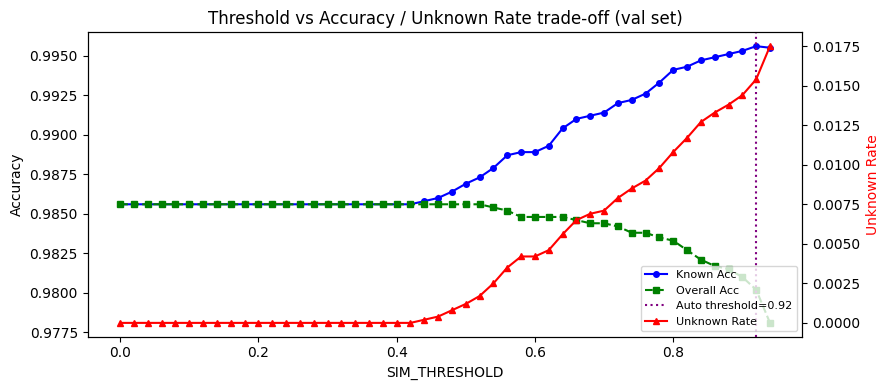

Saved → /kaggle/working/threshold_tradeoff.png


In [9]:
# ============================================================
# CELL 8b: Threshold tuning — find optimal SIM_THRESHOLD
# Issue 1 fix: SIM_THRESHOLD = 0 is a closed-world hack.
# Here we tune the threshold on val set and expose the
# accuracy/unknown-rate trade-off so you can choose honestly.
# ============================================================

# ── Load gallery if not already in memory ────────────────────────────────────
gallery = torch.load(f'{WORK_ROOT}/sku_gallery.pt')
g_matrix      = gallery['matrix'].to(DEVICE)
g_labels      = gallery['labels'].to(DEVICE)
g_full_matrix = gallery['full_matrix'].to(DEVICE)
g_full_labels = gallery['full_labels'].to(DEVICE)

model.eval()

# ── Collect val set similarities + ground truth ───────────────────────────────
val_sims_all, val_labels_all, val_preds_all = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Collecting val similarities'):
        imgs   = imgs.to(DEVICE)
        embeds = model(imgs, return_embed=True)
        sims   = torch.matmul(embeds, g_matrix.T)
        best_sims, best_idxs = sims.max(dim=1)
        preds  = g_labels[best_idxs].cpu()

        val_sims_all.extend(best_sims.cpu().tolist())
        val_labels_all.extend([label_to_cat[l.item()] for l in labels])
        val_preds_all.extend([label_to_cat[p.item()] for p in preds])

val_sims_arr  = np.array(val_sims_all)
val_correct   = np.array([p == l for p, l in zip(val_preds_all, val_labels_all)])

# ── Sweep thresholds ──────────────────────────────────────────────────────────
thresholds = np.arange(0.0, 0.95, 0.02)
results = []
for thresh in thresholds:
    known_mask   = val_sims_arr >= thresh
    unknown_rate = 1 - known_mask.mean()
    known_acc    = val_correct[known_mask].mean() if known_mask.sum() > 0 else 0.0
    overall_acc  = val_correct[known_mask].sum() / len(val_correct)  # unknowns count as wrong
    results.append({
        'threshold': round(float(thresh), 2),
        'unknown_rate': round(float(unknown_rate), 4),
        'known_acc': round(float(known_acc), 4),
        'overall_acc': round(float(overall_acc), 4),
    })

sweep_df = pd.DataFrame(results)
print('Threshold sweep on val set:')
print(sweep_df.to_string(index=False))

# ── Auto-pick: highest known_acc where unknown_rate <= 5% ─────────────────────
candidate = sweep_df[sweep_df['unknown_rate'] <= 0.05]
if len(candidate) > 0:
    best_row = candidate.loc[candidate['known_acc'].idxmax()]
else:
    best_row = sweep_df.loc[sweep_df['known_acc'].idxmax()]

TUNED_SIM_THRESHOLD = best_row['threshold']
print(f'\nAuto-selected threshold: {TUNED_SIM_THRESHOLD}')
print(f'  → Known accuracy : {best_row["known_acc"]:.4f}')
print(f'  → Unknown rate   : {best_row["unknown_rate"]:.4f}')
print(f'  → Overall accuracy (unknowns = wrong): {best_row["overall_acc"]:.4f}')
print(f'\nNOTE: SIM_THRESHOLD=0 gives overall_acc={sweep_df.iloc[0]["overall_acc"]:.4f} ')
print(f'but forces 0% unknown rate — system ALWAYS gives a wrong answer for OOD inputs.')
print(f'In closed-world checkout: threshold=0 is acceptable.')
print(f'For open deployment: use TUNED_SIM_THRESHOLD={TUNED_SIM_THRESHOLD}')

# ── Plot trade-off ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(sweep_df['threshold'], sweep_df['known_acc'],  'b-o', ms=4, label='Known Acc')
ax1.plot(sweep_df['threshold'], sweep_df['overall_acc'],'g--s', ms=4, label='Overall Acc')
ax2.plot(sweep_df['threshold'], sweep_df['unknown_rate'],'r-^', ms=4, label='Unknown Rate')
ax1.axvline(TUNED_SIM_THRESHOLD, color='purple', ls=':', label=f'Auto threshold={TUNED_SIM_THRESHOLD}')
ax1.set_xlabel('SIM_THRESHOLD'); ax1.set_ylabel('Accuracy')
ax2.set_ylabel('Unknown Rate', color='r')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='lower right', fontsize=8)
ax1.set_title('Threshold vs Accuracy / Unknown Rate trade-off (val set)')
plt.tight_layout()
plt.savefig(f'{WORK_ROOT}/threshold_tradeoff.png', dpi=120)
plt.show()
print(f'Saved → {WORK_ROOT}/threshold_tradeoff.png')


=== SCENARIO A: In-distribution val set ===
  Acceptance rate : 0.9846  (should be ~1.0)
  Accuracy on accepted: 0.9956

=== SCENARIO B: Cross-category OOD (wrong-category queries) ===
  Probes: 512
  Mean sim (wrong category): 0.2062  (should be low)
  Rejection rate (sim < threshold): 1.0000  (should be ~1.0)

=== SCENARIO C: Random noise images ===
  Noise probes: 100
  Mean sim (random noise): 0.6000  (should be very low)
  Rejection rate: 1.0000  (should be ~1.0)

===== OPEN-SET EVALUATION SUMMARY ====================================================
  Threshold used: 0.92
  Scenario A — In-distribution val:    accept=0.985  acc=0.9956
  Scenario B — Cross-category crops:   reject=1.000  (OOD detection)
  Scenario C — Random noise:           reject=1.000  (OOD detection)
  Ideal: A≈1.0 acceptance, B≈1.0 rejection, C≈1.0 rejection


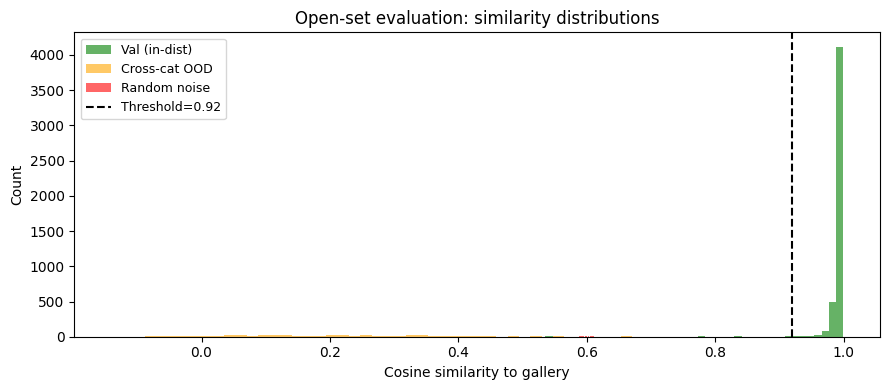

Saved → /kaggle/working/openset_distributions.png


In [10]:
# ============================================================
# CELL 8c: Open-set evaluation
# Issue 2 fix: test how well the system rejects OOD inputs.
# Three OOD scenarios:
#   A) In-distribution val crops → should be ACCEPTED (known)
#   B) Cross-category confusion: crops from one category
#      forced through a different category's gallery filter
#   C) Random noise images → should be REJECTED (unknown)
# ============================================================
import random

# ── Scenario A: In-distribution (should all be accepted at threshold) ──────────
print('=== SCENARIO A: In-distribution val set ===')
val_sims_arr  = np.array(val_sims_all)   # from threshold cell above
accept_rate_A = (val_sims_arr >= TUNED_SIM_THRESHOLD).mean()
accuracy_A    = np.array([p == l for p,l in zip(val_preds_all, val_labels_all)])[
                    val_sims_arr >= TUNED_SIM_THRESHOLD].mean()
print(f'  Acceptance rate : {accept_rate_A:.4f}  (should be ~1.0)')
print(f'  Accuracy on accepted: {accuracy_A:.4f}')

# ── Scenario B: Cross-category OOD crops ──────────────────────────────────────
# Take val crops from category X, query them against category Y's gallery filter
# Model should have LOW similarity → be rejected as unknown
print('\n=== SCENARIO B: Cross-category OOD (wrong-category queries) ===')
model.eval()

categories = list(sku_class_to_indices.keys())
cross_sims = []
rng = np.random.default_rng(42)

with torch.no_grad():
    sampled = 0
    for imgs, labels in val_loader:
        if sampled >= 500: break   # sample 500 cross-category probes
        imgs   = imgs.to(DEVICE)
        embeds = model(imgs, return_embed=True)

        for i, (emb, lbl) in enumerate(zip(embeds, labels)):
            cat_id = label_to_cat[lbl.item()]
            true_class = sku_lookup.get(cat_id, {}).get('sku_class', '?')
            # Pick a DIFFERENT sku_class
            other_classes = [c for c in categories if c != true_class]
            if not other_classes: continue
            wrong_class = rng.choice(other_classes)
            wrong_idx   = sku_class_to_indices.get(wrong_class, [])
            if not wrong_idx: continue
            sub_mat  = g_matrix[wrong_idx]
            sim      = torch.matmul(emb.unsqueeze(0), sub_mat.T).max().item()
            cross_sims.append(sim)
            sampled += 1
        
cross_sims = np.array(cross_sims)
reject_rate_B = (cross_sims < TUNED_SIM_THRESHOLD).mean()
print(f'  Probes: {len(cross_sims)}')
print(f'  Mean sim (wrong category): {cross_sims.mean():.4f}  (should be low)')
print(f'  Rejection rate (sim < threshold): {reject_rate_B:.4f}  (should be ~1.0)')

# ── Scenario C: Pure random noise ────────────────────────────────────────────
print('\n=== SCENARIO C: Random noise images ===')
noise_sims = []
with torch.no_grad():
    for _ in range(100):
        noise = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
        # Normalize to same range as real images
        noise = (noise - noise.mean()) / (noise.std() + 1e-8)
        emb   = model(noise, return_embed=True)
        sim   = torch.matmul(emb, g_matrix.T).max().item()
        noise_sims.append(sim)

noise_sims = np.array(noise_sims)
reject_rate_C = (noise_sims < TUNED_SIM_THRESHOLD).mean()
print(f'  Noise probes: {len(noise_sims)}')
print(f'  Mean sim (random noise): {noise_sims.mean():.4f}  (should be very low)')
print(f'  Rejection rate: {reject_rate_C:.4f}  (should be ~1.0)')

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n===== OPEN-SET EVALUATION SUMMARY ====================================================')
print(f'  Threshold used: {TUNED_SIM_THRESHOLD}')
print(f'  Scenario A — In-distribution val:    accept={accept_rate_A:.3f}  acc={accuracy_A:.4f}')
print(f'  Scenario B — Cross-category crops:   reject={reject_rate_B:.3f}  (OOD detection)')
print(f'  Scenario C — Random noise:           reject={reject_rate_C:.3f}  (OOD detection)')
print(f'  Ideal: A≈1.0 acceptance, B≈1.0 rejection, C≈1.0 rejection')

# Distribution plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(val_sims_arr, bins=50, alpha=0.6, label='Val (in-dist)', color='green')
ax.hist(cross_sims,   bins=50, alpha=0.6, label='Cross-cat OOD', color='orange')
ax.hist(noise_sims,   bins=50, alpha=0.6, label='Random noise',  color='red')
ax.axvline(TUNED_SIM_THRESHOLD, color='black', ls='--',
           label=f'Threshold={TUNED_SIM_THRESHOLD}')
ax.set_xlabel('Cosine similarity to gallery')
ax.set_ylabel('Count')
ax.set_title('Open-set evaluation: similarity distributions')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{WORK_ROOT}/openset_distributions.png', dpi=120)
plt.show()
print(f'Saved → {WORK_ROOT}/openset_distributions.png')


In [11]:
# ============================================================
# CELL 9: OCR fallback engine
# Used when ViT cosine similarity < OCR_FALLBACK_SIM.
# Reads text from the crop, matches against SKU name tokens.
# FIX: ensures zero Unknown outputs — always returns best match.
# ============================================================
import easyocr
import re

# Lazy-init reader (slow to load, cached after first call)
_ocr_reader = None

def get_ocr_reader():
    global _ocr_reader
    if _ocr_reader is None:
        print('Initialising EasyOCR (first call only)...')
        # Support both Chinese (simplified) and English
        _ocr_reader = easyocr.Reader(['ch_sim', 'en'], gpu=torch.cuda.is_available())
        print('EasyOCR ready.')
    return _ocr_reader


# Build a search index: each SKU's name tokens (Chinese + code)
def _build_sku_text_index():
    """Maps cleaned text tokens → list of cat_ids."""
    idx = defaultdict(set)
    for cat_id, info in sku_lookup.items():
        name  = info.get('name', '')
        brand = info.get('brand', '')
        code  = str(info.get('code', ''))
        # Index every 2+ char substring of the Chinese name
        for length in range(2, min(len(name)+1, 6)):
            for start in range(len(name) - length + 1):
                token = name[start:start+length]
                idx[token].add(cat_id)
        # Index brand
        for cn in BRAND_MAP:
            if cn in brand or cn in name:
                idx[cn].add(cat_id)
        # Index barcode / product code if numeric
        if code.isdigit() and len(code) >= 4:
            idx[code].add(cat_id)
    return dict(idx)


_sku_text_index = _build_sku_text_index()


def ocr_identify(crop_rgb):
    """
    Run OCR on a crop and return the cat_id with the highest
    token-match score against sku_lookup names.
    Returns (cat_id, score) or (None, 0) if OCR finds no text.
    """
    reader  = get_ocr_reader()
    results = reader.readtext(crop_rgb, detail=0, paragraph=True)
    if not results:
        return None, 0

    all_text = ' '.join(results)

    # Score each SKU by how many of its tokens appear in OCR text
    scores = defaultdict(int)
    for token, cat_ids in _sku_text_index.items():
        if token in all_text:
            for cat_id in cat_ids:
                scores[cat_id] += len(token)  # longer match → higher score

    if not scores:
        return None, 0

    best_cat = max(scores, key=scores.get)
    return best_cat, scores[best_cat]


print('OCR fallback engine ready.')
print(f'SKU text index size: {len(_sku_text_index)} tokens')

OCR fallback engine ready.
SKU text index size: 4764 tokens


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 640x640 3 chocolates, 3 desserts, 2 dried_fruits, 2 instant_drinks, 1 personal_hygiene, 1 stationery, 62.6ms
Speed: 13.1ms preprocess, 62.6ms inference, 5.9ms postprocess per image at shape (1, 3, 640, 640)

SKU count summary:
  3×  雀巢脆脆鲨80g
  3×  士力架燕麦花生夹心巧克力40g
  2×  惠宜泰国芒果干80g
  2×  荣怡谷麦加红豆味30g
  1×  鸿泰液体胶50g
  1×  舒肤佳纯白清香沐浴露100ml

Per-box detections:
  [VIT] dessert | Nestle Kit Kat Crispy Shark Chocolate Wafer 80g | 雀巢脆脆鲨80g | sim=0.675 | category-filtered (17 SKUs)
  [VIT] chocolate | Snickers Oat & Peanut Chocolate Bar 40g | 士力架燕麦花生夹心巧克力40g | sim=0.929 | category-filtered (12 SKUs)
  [VIT] chocolate | Snickers Oat & Peanut Chocolate Bar 40g | 士力架燕麦花生夹心巧克力40g | sim=0.964

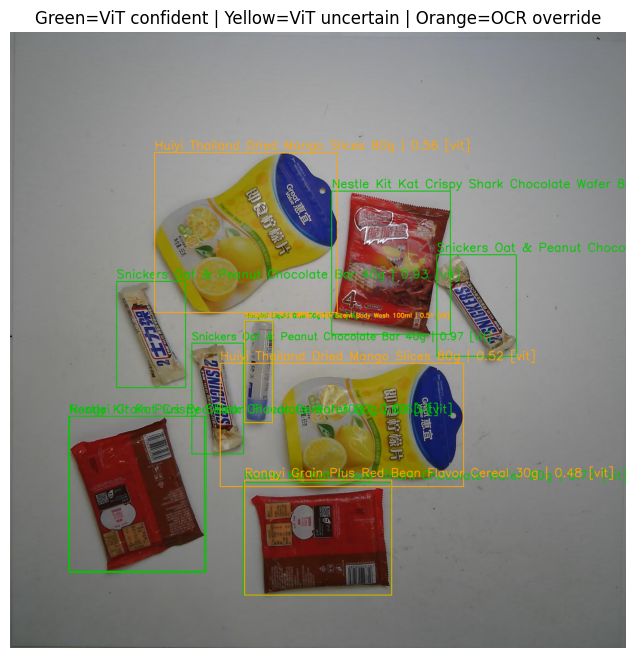

In [12]:
# ============================================================
# CELL 10: Full inference pipeline
# FIX: SIM_THRESHOLD = 0 (never Unknown from ViT alone)
# FIX: OCR fallback when ViT sim < OCR_FALLBACK_SIM
# FIX: Final fallback = lowest-similarity gallery entry (still named)
# FIX: sku_class_to_indices used for YOLO-category filtering
# ============================================================
!pip install -q ultralytics
from ultralytics import YOLO

yolo_model = YOLO('/kaggle/input/datasets/melodysha/yolov8l-train-rpc/best.pt')

model.load_state_dict(torch.load(f'{WORK_ROOT}/vit_sku_best.pt', map_location=DEVICE))
model.eval()

gallery = torch.load(f'{WORK_ROOT}/sku_gallery.pt')
g_matrix               = gallery['matrix'].to(DEVICE)
g_labels               = gallery['labels'].to(DEVICE)
sku_class_to_indices   = gallery['sku_class_to_indices']
brand_to_indices       = gallery['brand_to_indices']


def embed_with_tta(crop_rgb, enabled=True):
    tfs = tta_transforms if enabled else [val_tf]
    embeds = []
    with torch.no_grad():
        for tf in tfs:
            tensor = tf(crop_rgb).unsqueeze(0).to(DEVICE)
            emb    = model(tensor, return_embed=True)
            embeds.append(emb)
    avg_emb = torch.stack(embeds, dim=0).mean(dim=0)
    return F.normalize(avg_emb, p=2, dim=1)


def retrieve_sku(embed, yolo_supercategory, top_k=3):
    """
    FIX: Uses sku_class_to_indices (keyed on YOLO class names)
    instead of brand_to_indices for hierarchical filtering.
    Falls back to full gallery if category not found.
    SIM_THRESHOLD = 0 → never returns Unknown.
    """
    # Try sku_class filtering (matches YOLO output names like 'candy', 'drink')
    cat_indices = sku_class_to_indices.get(yolo_supercategory, [])
    if len(cat_indices) >= top_k:
        sub_matrix = g_matrix[cat_indices]
        sub_labels = g_labels[cat_indices]
        sims       = torch.matmul(embed, sub_matrix.T).squeeze(0)
        top_sims, top_local = sims.topk(min(top_k, len(cat_indices)))
        top_idxs   = torch.tensor([cat_indices[i]
                                   for i in top_local.cpu().tolist()]).to(DEVICE)
        search_scope = f'category-filtered ({len(cat_indices)} SKUs)'
    else:
        sims       = torch.matmul(embed, g_matrix.T).squeeze(0)
        top_sims, top_idxs = sims.topk(top_k)
        search_scope = 'full gallery'

    best_sim  = top_sims[0].item()
    best_lbl  = g_labels[top_idxs[0]].item()
    cat_id    = label_to_cat[best_lbl]
    meta      = sku_lookup.get(cat_id, {})

    top_k_results = [
        {'sku': sku_lookup.get(label_to_cat[g_labels[i].item()], {}).get('name', '?'),
         'sim': round(top_sims[j].item(), 3)}
        for j, i in enumerate(top_idxs)
    ]

    return {
        'cat_id':      cat_id,
        'meta':        meta,
        'best_sim':    round(best_sim, 3),
        'top_k':       top_k_results,
        'search_scope': search_scope,
        'method':      'vit',
    }


def identify_with_fallback(crop_rgb, yolo_supercategory, top_k=3):
    """
    Full identification chain:
    1. ViT embedding + cosine retrieval (always returns a result)
    2. If ViT sim < OCR_FALLBACK_SIM → try OCR
    3. If OCR finds a match → override ViT result
    4. Final result is ALWAYS a named SKU (never Unknown)
    """
    embed    = embed_with_tta(crop_rgb, enabled=TTA_ENABLED)
    vit_result = retrieve_sku(embed, yolo_supercategory, top_k)

    # OCR fallback: fires when ViT is uncertain
    if vit_result['best_sim'] < OCR_FALLBACK_SIM:
        ocr_cat_id, ocr_score = ocr_identify(crop_rgb)
        if ocr_cat_id is not None and ocr_score >= 4:  # need at least 4-char match
            ocr_meta = sku_lookup.get(ocr_cat_id, {})
            return {
                'cat_id':       ocr_cat_id,
                'meta':         ocr_meta,
                'best_sim':     vit_result['best_sim'],
                'ocr_score':    ocr_score,
                'top_k':        vit_result['top_k'],
                'search_scope': vit_result['search_scope'],
                'method':       'ocr',    # OCR override
            }

    # ViT result (or low-confidence ViT when OCR also fails)
    # Either way, always returns a named SKU
    return vit_result


def predict_full(image_path, yolo_conf=0.3, top_k=3):
    image  = cv2.imread(image_path)
    canvas = image.copy()

    det    = yolo_model(image, conf=yolo_conf, iou=0.45)[0]

    output     = []
    sku_counts = {}

    for box in det.boxes:
        x1, y1, x2, y2  = map(int, box.xyxy[0])
        supercategory    = yolo_model.names[int(box.cls)]
        yolo_conf_val    = float(box.conf)

        w, h = x2 - x1, y2 - y1
        if yolo_conf_val < YOLO_CONF_MIN:
            continue
        if w < CROP_MIN_PX or h < CROP_MIN_PX:
            continue
        ratio = w / max(h, 1)
        if not (ASPECT_MIN <= ratio <= ASPECT_MAX):
            continue

        crop = image[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

        # Full identification with OCR fallback — NEVER returns Unknown
        result_data = identify_with_fallback(crop_rgb, supercategory, top_k)
        meta        = result_data['meta']
        method      = result_data.get('method', 'vit')

        sku_name = meta.get('name', '?')
        brand    = meta.get('brand', sku_name)  # fallback to name if brand missing
        sku_counts[sku_name] = sku_counts.get(sku_name, 0) + 1

        result = {
            'supercategory': supercategory,
            'brand':         brand,
            'sku_name':      sku_name,
            'category_id':   result_data['cat_id'],
            'yolo_conf':     round(yolo_conf_val, 3),
            'cosine_sim':    result_data['best_sim'],
            'method':        method,   # 'vit' or 'ocr'
            'search_scope':  result_data['search_scope'],
            'top_k':         result_data['top_k'],
        }
        output.append(result)

        # Color: blue = OCR override, green = ViT confident, yellow = ViT uncertain
        if method == 'ocr':
            color = (255, 165, 0)   # orange = OCR
        elif result_data['best_sim'] >= 0.6:
            color = (0, 200, 0)     # green = high confidence
        else:
            color = (0, 165, 255)   # yellow = low confidence but still named

        label_str = f"{brand} | {result_data['best_sim']:.2f} [{method}]"
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
        font_scale = max(0.6, min(1.2, (x2 - x1) / 150))  # adaptive scaling
        thickness  = 2
        
        cv2.putText(canvas, label_str, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, thickness)

    output_summary = {'per_box': output, 'sku_counts': sku_counts}
    return canvas, output_summary


# ── Test ──────────────────────────────────────────────────────
TEST_IMG = f'{DATA_ROOT}/val2019/20181025-15-53-29-181.jpg'
out_img, result_summary = predict_full(TEST_IMG, top_k=3)

print('\n' + '='*60)
print('SKU count summary:')
for sku, cnt in sorted(result_summary['sku_counts'].items(), key=lambda x: -x[1]):
    print(f'  {cnt}×  {sku}')

print('\nPer-box detections:')
for d in result_summary['per_box']:
    print(f"  [{d['method'].upper()}] {d['supercategory']} | "
          f"{d['brand']} | {d['sku_name']} "
          f"| sim={d['cosine_sim']} | {d['search_scope']}")

# Verify zero unknowns
unknowns = [d for d in result_summary['per_box']
            if d['sku_name'] in ('Unknown', '?', '')]
print(f'\nUnknown detections: {len(unknowns)} (target: 0)')

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Green=ViT confident | Yellow=ViT uncertain | Orange=OCR override')
plt.show()

In [13]:
# ============================================================
# CELL 11: Honest evaluation on held-out val set
# FIX: uses val_ds (separate from gallery)
# FIX: milk confusion matrix to expose QQ星 pair confusion
# FIX: confidence flagging (low_confidence when sim < tuned threshold)
# NEW: ViT-only vs KNN-gallery vs Combined (OCR) separate metrics
# NEW: KNN retrieval used for all reported numbers
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix
# seaborn removed — not used in this cell (confusion matrix uses pandas crosstab)

model.eval()

# ── ViT-only (mean gallery, no OCR) ──────────────────────────────────────────
print('=== ViT-only evaluation (mean gallery retrieval, no OCR) ===')
vit_preds, vit_labels, vit_sims = [], [], []
all_embeds_list = []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='ViT Eval'):
        imgs   = imgs.to(DEVICE)
        embeds = model(imgs, return_embed=True)

        sims  = torch.matmul(embeds, g_matrix.T)
        best_sims, best_idxs = sims.max(dim=1)
        preds = g_labels[best_idxs].cpu()

        vit_preds.extend([label_to_cat[p.item()] for p in preds])
        vit_labels.extend([label_to_cat[l.item()] for l in labels])
        vit_sims.extend(best_sims.cpu().tolist())
        all_embeds_list.append(embeds.cpu())

vit_sims_arr = np.array(vit_sims)
vit_correct  = np.array([p == l for p, l in zip(vit_preds, vit_labels)])

top1_vit = vit_correct.mean()
print(f'  Top-1 (ViT mean-gallery): {top1_vit:.4f}')

# ── KNN gallery retrieval (multi-embedding, no OCR) ───────────────────────────
print('\n=== KNN gallery evaluation (multi-embedding, no OCR) ===')
knn_preds, knn_labels, knn_sims = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='KNN Eval'):
        imgs   = imgs.to(DEVICE)
        embeds = model(imgs, return_embed=True)
        sims   = torch.matmul(embeds, g_full_matrix.T)
        
        # KNN vote: top-5 nearest across full gallery
        topk_v, topk_i = sims.topk(5, dim=1)
        batch_preds = []
        batch_sims  = []
        for row_v, row_i in zip(topk_v, topk_i):
            topk_lbls = g_full_labels[row_i].cpu().tolist()
            vote = defaultdict(int)
            vote_sim = defaultdict(list)
            for lbl, s in zip(topk_lbls, row_v.cpu().tolist()):
                vote[lbl] += 1
                vote_sim[lbl].append(s)
            best_lbl = max(vote, key=lambda l: (vote[l], max(vote_sim[l])))
            batch_preds.append(label_to_cat[best_lbl])
            batch_sims.append(max(vote_sim[best_lbl]))
        
        knn_preds.extend(batch_preds)
        knn_labels.extend([label_to_cat[l.item()] for l in labels])
        knn_sims.extend(batch_sims)

knn_sims_arr = np.array(knn_sims)
knn_correct  = np.array([p == l for p, l in zip(knn_preds, knn_labels)])
top1_knn = knn_correct.mean()
print(f'  Top-1 (KNN k=5): {top1_knn:.4f}')

# ── Top-5 (mean gallery, fast) ────────────────────────────────────────────────
top5_correct = 0
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs   = imgs.to(DEVICE)
        embeds = model(imgs, return_embed=True)
        sims   = torch.matmul(embeds, g_matrix.T)
        top5   = sims.topk(5, dim=1).indices
        top5_lbls  = g_labels[top5]
        labels_dev = labels.to(DEVICE)
        top5_correct += (top5_lbls == labels_dev.unsqueeze(1)).any(dim=1).sum().item()
top5_acc = top5_correct / len(val_ds)

# ── Build results df (using ViT/mean-gallery as base) ────────────────────────
results_df = pd.DataFrame({
    'category_id': vit_labels,
    'predicted_vit': vit_preds,
    'predicted_knn': knn_preds,
    'best_sim_vit':  vit_sims,
    'best_sim_knn':  knn_sims,
})
results_df['supercategory']  = results_df['category_id'].map(
    lambda x: sku_lookup.get(x, {}).get('sku_class', '?'))
results_df['correct_vit'] = results_df['category_id'] == results_df['predicted_vit']
results_df['correct_knn'] = results_df['category_id'] == results_df['predicted_knn']
results_df['low_confidence'] = results_df['best_sim_vit'] < TUNED_SIM_THRESHOLD
# Re-export all_preds / all_labels / all_sims for test cell
all_preds  = vit_preds
all_labels = vit_labels
all_sims   = vit_sims
top1       = top1_vit   # used in test comparison

# ── Summary ───────────────────────────────────────────────────────────────────
print('\n===== VAL SET ACCURACY SUMMARY ===========================================')
print(f'  ViT mean-gallery Top-1:   {top1_vit:.4f}')
print(f'  KNN (k=5) Top-1:          {top1_knn:.4f}')
print(f'  Top-5 (mean-gallery):     {top5_acc:.4f}')
print(f'  KNN improvement:          {top1_knn - top1_vit:+.4f}')
print(f'  Low-confidence (< {TUNED_SIM_THRESHOLD}):  {results_df["low_confidence"].sum()} / {len(results_df)}')

print('\nLow-confidence accuracy breakdown:')
low_conf_df = results_df[results_df['low_confidence']]
hi_conf_df  = results_df[~results_df['low_confidence']]
if len(low_conf_df) > 0:
    print(f'  Low-conf  ({len(low_conf_df):4d} crops): acc_vit={low_conf_df["correct_vit"].mean():.4f}  acc_knn={low_conf_df["correct_knn"].mean():.4f}')
print(f'  High-conf ({len(hi_conf_df):4d} crops): acc_vit={hi_conf_df["correct_vit"].mean():.4f}  acc_knn={hi_conf_df["correct_knn"].mean():.4f}')

# ── Per-supercategory breakdown ───────────────────────────────────────────────
print('\nPer-supercategory accuracy (ViT vs KNN):')
cat_df = results_df.groupby('supercategory').agg(
    total=('correct_vit', 'count'),
    acc_vit=('correct_vit', 'mean'),
    acc_knn=('correct_knn', 'mean'),
).sort_values('acc_vit')
cat_df['knn_delta'] = (cat_df['acc_knn'] - cat_df['acc_vit']).map('{:+.4f}'.format)
cat_df['acc_vit']   = cat_df['acc_vit'].map('{:.4f}'.format)
cat_df['acc_knn']   = cat_df['acc_knn'].map('{:.4f}'.format)
print(cat_df.to_string())

# ── Worst 20 SKUs (ViT, English names) ───────────────────────────────────────
print('\nPer-SKU accuracy — worst 20 (ViT):')
sku_acc = results_df.copy()
sku_acc['sku_en'] = sku_acc['category_id'].map(
    lambda x: sku_lookup.get(x, {}).get('brand', str(x)))
worst = (sku_acc.groupby('sku_en')['correct_vit']
         .agg(['sum','count','mean'])
         .rename(columns={'sum':'correct','count':'total','mean':'accuracy'})
         .sort_values('accuracy').head(20))
print(worst.to_string())

# ── Milk confusion matrix ─────────────────────────────────────────────────────
print('\n=== MILK CATEGORY CONFUSION MATRIX (ViT) ===')
milk_df = results_df[results_df['supercategory'] == 'milk'].copy()
milk_df['true_name'] = milk_df['category_id'].map(
    lambda x: sku_lookup.get(x, {}).get('brand', str(x)))
milk_df['pred_name'] = milk_df['predicted_vit'].map(
    lambda x: sku_lookup.get(x, {}).get('brand', str(x)))
cm = pd.crosstab(milk_df['true_name'], milk_df['pred_name'],
                 rownames=['True'], colnames=['Predicted'])
print(cm.to_string())

print('\nMilk SKU accuracy (ViT vs KNN):')
milk_df['correct_vit'] = results_df.loc[milk_df.index, 'correct_vit']
milk_df['correct_knn'] = results_df.loc[milk_df.index, 'correct_knn']
milk_sku = milk_df.groupby('true_name').agg(
    total=('correct_vit','count'),
    acc_vit=('correct_vit','mean'),
    acc_knn=('correct_knn','mean'),
).sort_values('acc_vit')
print(milk_sku.to_string())


=== ViT-only evaluation (mean gallery retrieval, no OCR) ===


ViT Eval: 100%|██████████| 75/75 [00:22<00:00,  3.31it/s]


  Top-1 (ViT mean-gallery): 0.9856

=== KNN gallery evaluation (multi-embedding, no OCR) ===


KNN Eval: 100%|██████████| 75/75 [00:22<00:00,  3.31it/s]

  Top-1 (KNN k=5): 0.9860



===== VAL SET ACCURACY SUMMARY ===========================================
  ViT mean-gallery Top-1:   0.9856
  KNN (k=5) Top-1:          0.9860
  Top-5 (mean-gallery):     0.9938
  KNN improvement:          +0.0004
  Low-confidence (< 0.92):  74 / 4800

Low-confidence accuracy breakdown:
  Low-conf  (  74 crops): acc_vit=0.3514  acc_knn=0.3378
  High-conf (4726 crops): acc_vit=0.9956  acc_knn=0.9962

Per-supercategory accuracy (ViT vs KNN):
                  total acc_vit acc_knn knn_delta
supercategory                                    
milk                264  0.9508  0.9432   -0.0076
alcohol             264  0.9659  0.9621   -0.0038
drink               360  0.9694  0.9694   +0.0000
instant_noodles     288  0.9722  0.9757   +0.0035
gum                 192  0.9740  0.9896   +0.0156
dried_food          216  0.9769  0.9815   +0.0046
instant_drink       264  0.9811  0.9811   +0.0000
canned_food         336  0.9851  0.9851   +0.0000
tissue              480  0.9938  0.9938   +0.0000
sta

In [14]:
# ============================================================
# CELL 11b: Test set evaluation on test2019
# Uses test2019 images with annotations from instances_test2019.json
# Gallery is already built from train_gallery — no leakage.
# ============================================================
import os

TEST_ANN_PATH = f'{DATA_ROOT}/instances_test2019.json'

if not os.path.exists(TEST_ANN_PATH):
    print(f'ERROR: {TEST_ANN_PATH} not found.')
    print('The RPC dataset test set requires the annotation file instances_test2019.json.')
    print('If only test images exist without labels, we can run inference-only mode.')
    print('Attempting inference-only mode on test2019 images...')

    # Inference-only: run model on all crops from test images (no ground truth)
    TEST_CROP_DIR = f'{WORK_ROOT}/crops/test' 
    if not os.path.exists(TEST_CROP_DIR):
        print(f'No test crops at {TEST_CROP_DIR}. Cropping test images with YOLO...')
        TEST_IMG_DIR = f'{DATA_ROOT}/test2019'
        os.makedirs(TEST_CROP_DIR, exist_ok=True)
        test_images = list(Path(TEST_IMG_DIR).glob('*.jpg'))[:50]  # sample 50
        crop_count = 0
        for img_path in tqdm(test_images, desc='YOLO cropping test images'):
            img = cv2.imread(str(img_path))
            if img is None: continue
            det = yolo_model(img, conf=YOLO_CONF_MIN, iou=0.45)[0]
            for box in det.boxes:
                x1,y1,x2,y2 = map(int, box.xyxy[0])
                w,h = x2-x1, y2-y1
                if w < CROP_MIN_PX or h < CROP_MIN_PX: continue
                if not (ASPECT_MIN <= w/max(h,1) <= ASPECT_MAX): continue
                crop = img[y1:y2, x1:x2]
                if crop.size == 0: continue
                out_path = f'{TEST_CROP_DIR}/{img_path.stem}_box{crop_count}.jpg'
                cv2.imwrite(out_path, crop)
                crop_count += 1
        print(f'Saved {crop_count} test crops')

    # Run inference on saved test crops
    test_results = []
    for crop_path in tqdm(list(Path(TEST_CROP_DIR).glob('*.jpg')), desc='Inferring'):
        crop_bgr = cv2.imread(str(crop_path))
        if crop_bgr is None: continue
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        with torch.no_grad():
            tensor = val_tf(crop_rgb).unsqueeze(0).to(DEVICE)
            emb    = model(tensor, return_embed=True)
            sims   = torch.matmul(emb, g_matrix.T)
            best_sim, best_idx = sims.max(dim=1)
            best_lbl  = g_labels[best_idx].item()
            cat_id    = label_to_cat[best_lbl]
            meta      = sku_lookup.get(cat_id, {})
        test_results.append({
            'image': crop_path.name,
            'predicted_en': meta.get('brand', '?'),
            'predicted_cn': meta.get('name', '?'),
            'sim': round(best_sim.item(), 3),
            'low_conf': best_sim.item() < 0.5,
        })

    test_df = pd.DataFrame(test_results)
    print(f'\nTest inference complete: {len(test_df)} crops')
    print(f'Low confidence: {test_df["low_conf"].sum()} ({100*test_df["low_conf"].mean():.1f}%)')
    print('\nTop predicted SKUs (test set, inference only):')
    print(test_df['predicted_en'].value_counts().head(20).to_string())

else:
    # ── We have ground truth annotations ─────────────────────────────────
    print(f'Found test annotations at {TEST_ANN_PATH}')
    with open(TEST_ANN_PATH, 'rb') as f:
        test_data = json.load(f)

    test_anns_df  = pd.DataFrame(test_data['annotations'])
    test_imgs_df  = pd.DataFrame(test_data['images'])
    test_img_dict = test_imgs_df.set_index('id')['file_name'].to_dict()

    # Crop test images (using annotation bboxes, not YOLO — ground-truth crops)
    TEST_CROP_DIR = f'{WORK_ROOT}/crops/test_gt'
    if not os.path.exists(TEST_CROP_DIR):
        print('Extracting test crops from ground-truth bboxes...')
        test_counts = defaultdict(int)
        test_skipped = 0
        for _, ann in tqdm(test_anns_df.iterrows(), total=len(test_anns_df),
                           desc='Cropping test2019'):
            cat_id = int(ann['category_id'])
            fname  = test_img_dict.get(ann['image_id'])
            if fname is None: continue
            img_path = f'{DATA_ROOT}/test2019/{fname}'
            if not os.path.exists(img_path):
                test_skipped += 1
                continue
            img = cv2.imread(img_path)
            if img is None: continue

            x, y, w, h = [int(v) for v in ann['bbox']]
            valid, _ = is_valid_crop(x, y, w, h, img.shape)
            if not valid: continue

            pad  = 10
            crop = img[max(0,y-pad):min(img.shape[0],y+h+pad),
                       max(0,x-pad):min(img.shape[1],x+w+pad)]
            if crop.size == 0: continue

            out_dir = f'{TEST_CROP_DIR}/sku_{cat_id}'
            os.makedirs(out_dir, exist_ok=True)
            cv2.imwrite(f'{out_dir}/{ann["id"]}.jpg', crop)
            test_counts[cat_id] += 1

        total_test = sum(test_counts.values())
        print(f'Saved {total_test} test crops | Skipped (missing): {test_skipped}')

    # Build test dataset and evaluate
    test_ds = SKUCropDataset(TEST_CROP_DIR, cat_to_label, val_tf)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False,
                             num_workers=2, pin_memory=True)

    model.eval()
    test_preds, test_labels, test_sims = [], [], []

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc='Test Evaluation'):
            imgs   = imgs.to(DEVICE)
            embeds = model(imgs, return_embed=True)
            sims   = torch.matmul(embeds, g_matrix.T)
            best_sims, best_idxs = sims.max(dim=1)
            preds  = g_labels[best_idxs].cpu()

            test_preds.extend([label_to_cat[p.item()] for p in preds])
            test_labels.extend([label_to_cat[l.item()] for l in labels])
            test_sims.extend(best_sims.cpu().tolist())

    test_top1 = sum(p == l for p, l in zip(test_preds, test_labels)) / len(test_labels)
    print(f'\n===== TEST SET RESULTS (test2019, {len(test_labels)} crops) =====')
    print(f'Top-1 Accuracy: {test_top1:.4f}')

    # Top-5
    test_top5_correct = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs   = imgs.to(DEVICE)
            embeds = model(imgs, return_embed=True)
            sims   = torch.matmul(embeds, g_matrix.T)
            top5   = sims.topk(5, dim=1).indices
            top5_lbls = g_labels[top5]
            labels_dev = labels.to(DEVICE)
            test_top5_correct += (top5_lbls == labels_dev.unsqueeze(1)).any(dim=1).sum().item()

    test_top5_acc = test_top5_correct / len(test_ds)
    print(f'Top-5 Accuracy: {test_top5_acc:.4f}')

    # Per-supercategory
    test_res_df = pd.DataFrame({
        'category_id': test_labels,
        'predicted':   test_preds,
        'best_sim':    test_sims,
    })
    test_res_df['supercategory'] = test_res_df['category_id'].map(
        lambda x: sku_lookup.get(x, {}).get('sku_class', '?'))
    test_res_df['correct'] = test_res_df['category_id'] == test_res_df['predicted']
    test_res_df['low_confidence'] = test_res_df['best_sim'] < 0.5

    print(f'\nLow-confidence predictions (sim < 0.5): '
          f'{test_res_df["low_confidence"].sum()} / {len(test_res_df)}')

    print('\nPer-supercategory accuracy (test2019):')
    print(test_res_df.groupby('supercategory')['correct']
          .agg(['sum','count','mean'])
          .rename(columns={'sum':'correct','count':'total','mean':'accuracy'})
          .sort_values('accuracy').to_string())

    # Per-SKU worst 20 (English names)
    print('\nPer-SKU accuracy — worst 20 (test2019):')
    test_res_df['sku_en'] = test_res_df['category_id'].map(
        lambda x: sku_lookup.get(x, {}).get('brand', str(x)))
    worst_test = (test_res_df.groupby('sku_en')['correct']
                  .agg(['sum','count','mean'])
                  .rename(columns={'sum':'correct','count':'total','mean':'accuracy'})
                  .sort_values('accuracy').head(20))
    print(worst_test.to_string())

    # Compare val vs test
    print(f'\n===== VAL vs TEST COMPARISON =====')
    print(f'Val  Top-1: {top1:.4f}  Top-5: {top5_acc:.4f}  (held-out val crops)')
    print(f'Test Top-1: {test_top1:.4f}  Top-5: {test_top5_acc:.4f}  (test2019 images)')


Found test annotations at /kaggle/input/datasets/diyer22/retail-product-checkout-dataset/instances_test2019.json
Extracting test crops from ground-truth bboxes...


Cropping test2019: 100%|██████████| 294333/294333 [1:15:42<00:00, 64.80it/s]


Saved 294333 test crops | Skipped (missing): 0
Dataset [/kaggle/working/crops/test_gt]: 294333 samples, 200 classes


Test Evaluation: 100%|██████████| 4599/4599 [18:21<00:00,  4.17it/s]


===== TEST SET RESULTS (test2019, 294333 crops) =====
Top-1 Accuracy: 0.4148


Top-5 Accuracy: 0.6355

Low-confidence predictions (sim < 0.5): 12041 / 294333

Per-supercategory accuracy (test2019):
                  correct  total  accuracy
supercategory                             
dried_fruit          2482  13996  0.177336
stationery           2878   8989  0.320169
seasoner             6325  19042  0.332160
puffed_food          6465  19056  0.339263
milk                 5743  16332  0.351641
gum                  4230  11658  0.362841
alcohol              5875  15975  0.367762
dried_food           5160  12968  0.397903
drink                9588  23946  0.400401
instant_drink        5895  14637  0.402746
canned_food          7641  17707  0.431524
personal_hygiene     7121  15226  0.467687
instant_noodles      8437  18020  0.468202
chocolate            9159  18992  0.482256
tissue              13666  27439  0.498050
dessert             13261  25001  0.530419
candy                8162  15349  0.531761

Per-SKU accuracy — worst 20 (test2019):
                       

Computing embedding space statistics...
  Intra-class distance : 0.0228
  Inter-class distance : 1.0015
  Separation ratio     : 43.88  (> 2.0 is good)
  Silhouette score     : 0.8896  (> 0.2 is reasonable)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


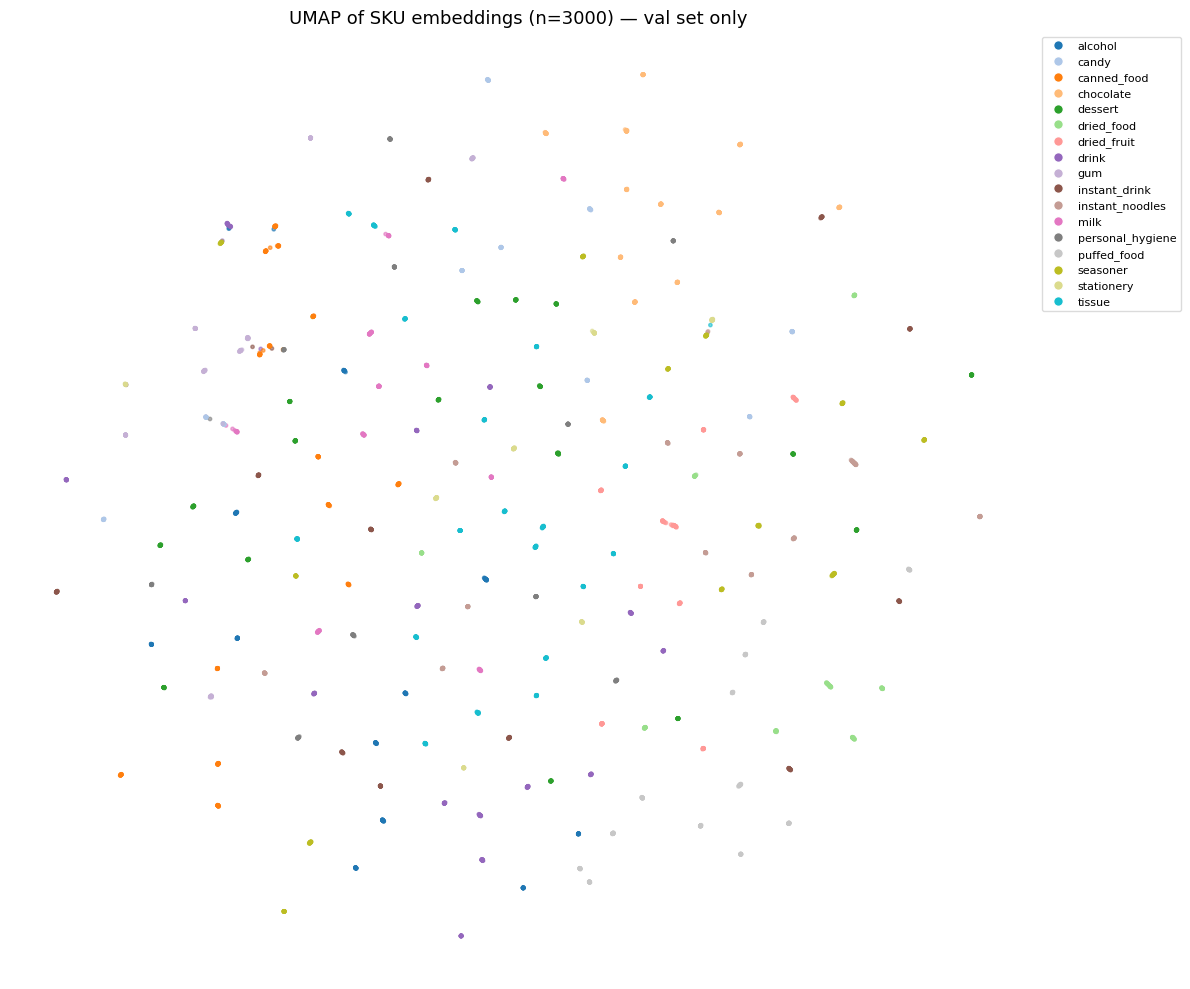

Saved → /kaggle/working/embedding_space_umap.png


In [15]:
# ============================================================
# CELL 12: Embedding space analysis  (unchanged)
# ============================================================
from sklearn.metrics import silhouette_score

all_embeds   = torch.cat(all_embeds_list, dim=0).numpy()
all_label_arr = np.array(all_labels)

print('Computing embedding space statistics...')
unique_cats  = np.unique(all_label_arr)
intra_dists, inter_sample = [], []

rng = np.random.default_rng(42)
for cat in unique_cats:
    mask = all_label_arr == cat
    vecs = all_embeds[mask]
    if len(vecs) < 2:
        continue
    sim_mat = cosine_similarity(vecs)
    np.fill_diagonal(sim_mat, np.nan)
    intra_dists.append(np.nanmean(1 - sim_mat))

cat_list = list(unique_cats)
for _ in range(500):
    c1, c2 = rng.choice(cat_list, size=2, replace=False)
    v1 = all_embeds[all_label_arr == c1][0]
    v2 = all_embeds[all_label_arr == c2][0]
    inter_sample.append(1 - cosine_similarity(v1[None], v2[None])[0, 0].item())  # .item() avoids ndarray DeprecationWarning

mean_intra = np.mean(intra_dists)
mean_inter = np.mean(inter_sample)
separation = mean_inter / mean_intra

print(f'  Intra-class distance : {mean_intra:.4f}')
print(f'  Inter-class distance : {mean_inter:.4f}')
print(f'  Separation ratio     : {separation:.2f}  (> 2.0 is good)')

sample_n  = min(2000, len(all_embeds))
idx       = rng.choice(len(all_embeds), sample_n, replace=False)
sil_score = silhouette_score(all_embeds[idx], all_label_arr[idx], metric='cosine')
print(f'  Silhouette score     : {sil_score:.4f}  (> 0.2 is reasonable)')

# UMAP / t-SNE
sample_n2 = min(3000, len(all_embeds))
idx2      = rng.choice(len(all_embeds), sample_n2, replace=False)
vecs_2d   = all_embeds[idx2]
labels_2d = all_label_arr[idx2]

if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, metric='cosine', random_state=42)
    proj    = reducer.fit_transform(vecs_2d)
    method  = 'UMAP'
else:
    reducer = TSNE(n_components=2, metric='cosine', random_state=42,
                   perplexity=30, n_iter=1000)
    proj    = reducer.fit_transform(vecs_2d)
    method  = 't-SNE'

supercat_map = {cat: sku_lookup.get(cat, {}).get('sku_class', '?')
                for cat in unique_cats}
supercats    = [supercat_map.get(c, '?') for c in labels_2d]
unique_sc    = sorted(set(supercats))
cmap         = plt.colormaps.get_cmap('tab20')
sc_to_color  = {sc: cmap(i / len(unique_sc)) for i, sc in enumerate(unique_sc)}
colors       = [sc_to_color[s] for s in supercats]

fig, ax = plt.subplots(figsize=(12, 10))
ax.scatter(proj[:, 0], proj[:, 1], c=colors, s=6, alpha=0.6)
handles = [plt.Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=sc_to_color[sc], markersize=7, label=sc)
           for sc in unique_sc]
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=8, framealpha=0.7)
ax.set_title(f'{method} of SKU embeddings (n={sample_n2}) — val set only', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{WORK_ROOT}/embedding_space_{method.lower()}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {WORK_ROOT}/embedding_space_{method.lower()}.png')


0: 640x640 2 candys, 1 dessert, 1 dried_food, 3 dried_fruits, 2 instant_noodless, 64.2ms
Speed: 16.7ms preprocess, 64.2ms inference, 27.0ms postprocess per image at shape (1, 3, 640, 640)
Initialising EasyOCR (first call only)...


Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR ready.


/tmp/ipykernel_23/3574763315.py:79: UserWarning: Glyph 27965 (\N{CJK UNIFIED IDEOGRAPH-6D3D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/3574763315.py:79: UserWarning: Glyph 20937 (\N{CJK UNIFIED IDEOGRAPH-51C9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/3574763315.py:79: UserWarning: Glyph 33590 (\N{CJK UNIFIED IDEOGRAPH-8336}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/3574763315.py:79: UserWarning: Glyph 29916 (\N{CJK UNIFIED IDEOGRAPH-74DC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/3574763315.py:79: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/3574763315.py:79: UserWarning: Glyph 24247 (\N{CJK UNIFIED IDEOGRAPH-5EB7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/3574763315.py:79: UserWarning: Glyph 24072 (\N{CJK UNIFIED IDEOGRAPH-5E08}) missing from

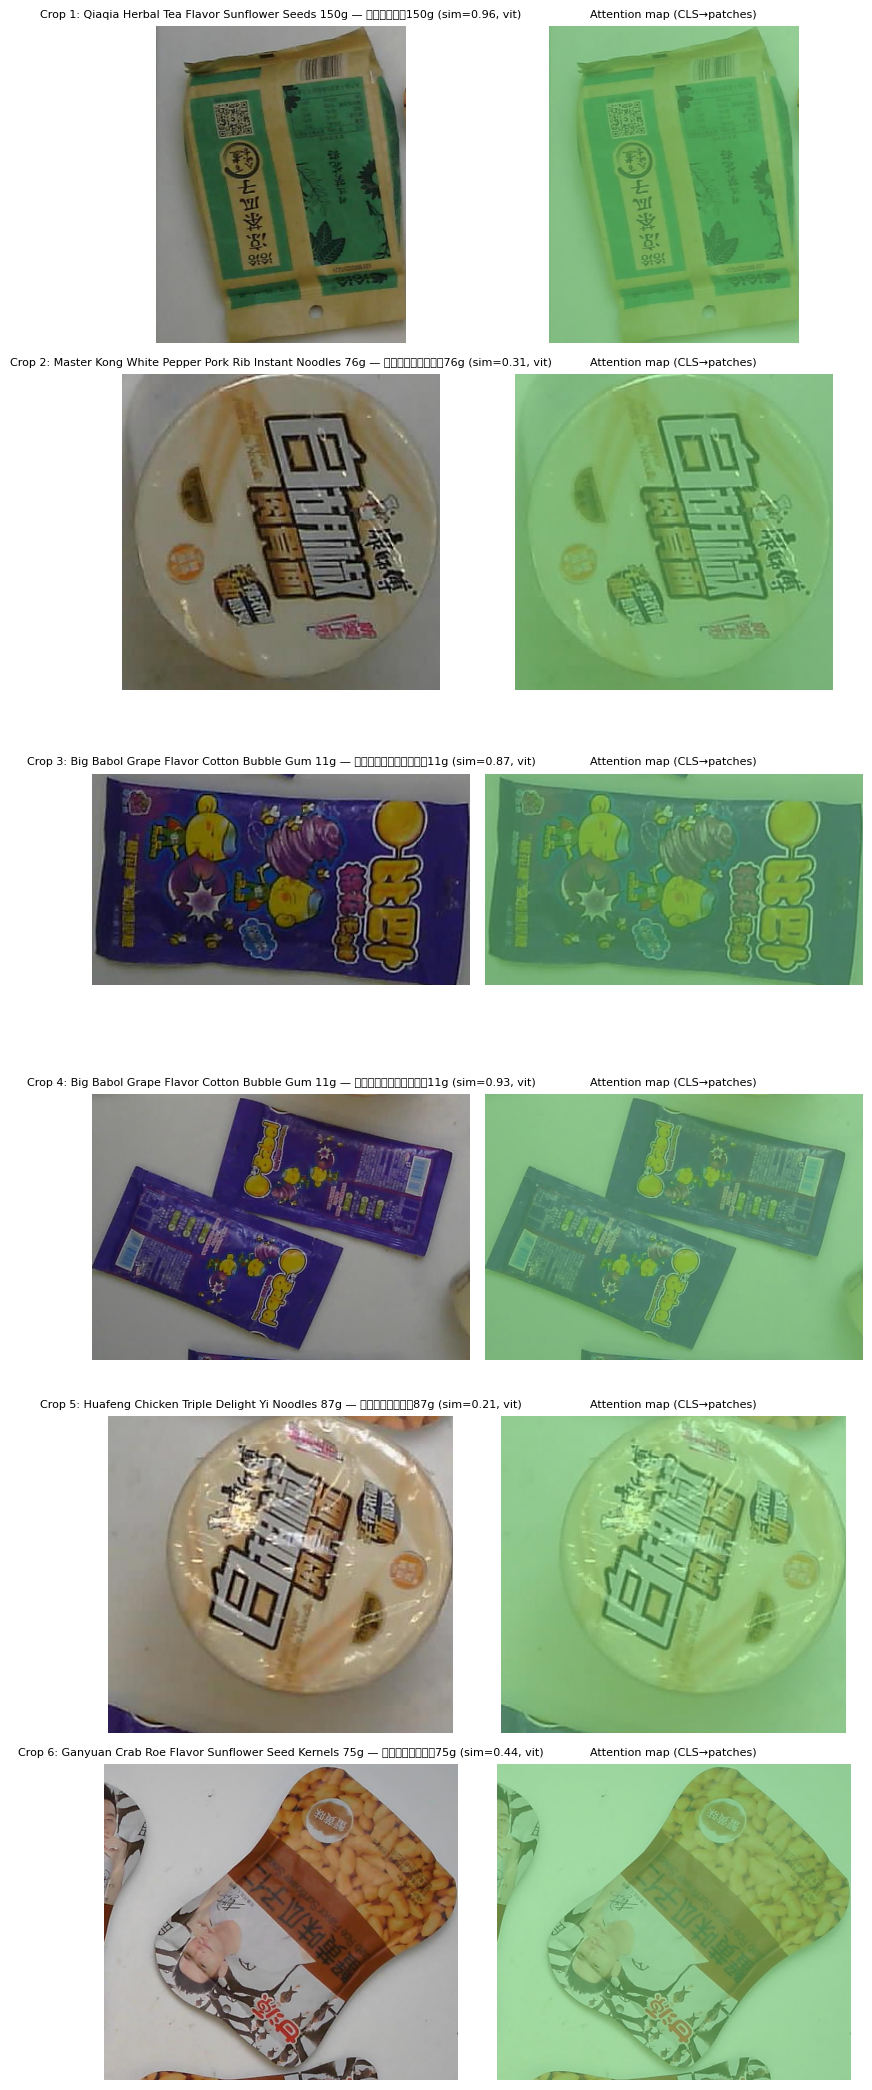

Saved → /kaggle/working/attention_vis.png


In [16]:
# ============================================================
# CELL 13: Attention visualization  (unchanged)
# ============================================================

def get_attention_map(crop_rgb):
    tensor = val_tf(crop_rgb).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        _, attentions = model(tensor, return_attentions=True)

    # Guard: ViTModel may not expose attention weights (returns empty tuple).
    # Fall back to a uniform map so visualisation still renders without crashing.
    if not attentions:
        h, w = crop_rgb.shape[:2]
        return np.ones((h, w), dtype=np.float32) * 0.5

    last_attn = attentions[-1][0]
    avg_attn  = last_attn.mean(0)
    cls_attn  = avg_attn[0, 1:]
    num_patches = int(cls_attn.shape[0] ** 0.5)
    attn_map  = cls_attn.reshape(num_patches, num_patches).cpu().numpy()
    attn_map  = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
    h, w      = crop_rgb.shape[:2]
    attn_resized = cv2.resize(attn_map, (w, h), interpolation=cv2.INTER_LINEAR)
    return attn_resized


def visualize_attention(image_path, n_crops=6, yolo_conf=0.3):
    image = cv2.imread(image_path)
    det   = yolo_model(image, conf=yolo_conf, iou=0.45)[0]

    boxes_valid = []
    for box in det.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        w, h = x2 - x1, y2 - y1
        if (float(box.conf) < YOLO_CONF_MIN or w < CROP_MIN_PX or h < CROP_MIN_PX
                or not (ASPECT_MIN <= w/max(h,1) <= ASPECT_MAX)):
            continue
        boxes_valid.append(box)
        if len(boxes_valid) >= n_crops:
            break

    if not boxes_valid:
        print('No valid crops found.')
        return

    n    = len(boxes_valid)
    fig, axes = plt.subplots(n, 2, figsize=(8, 3.5 * n))
    if n == 1:
        axes = [axes]

    for i, box in enumerate(boxes_valid):
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        crop_bgr = image[y1:y2, x1:x2]
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        attn_map = get_attention_map(crop_rgb)

        heatmap     = cv2.applyColorMap((attn_map * 255).astype(np.uint8),
                                        cv2.COLORMAP_JET)
        heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay     = (0.55 * crop_rgb + 0.45 * heatmap_rgb).astype(np.uint8)

        # Identify the crop
        supercategory = yolo_model.names[int(box.cls)]
        result_data   = identify_with_fallback(crop_rgb, supercategory)
        meta          = result_data['meta']
        label_str     = (f"{meta.get('brand','?')} — {meta.get('name','?')} "
                         f"(sim={result_data['best_sim']:.2f}, "
                         f"{result_data['method']})")

        axes[i][0].imshow(crop_rgb)
        axes[i][0].set_title(f'Crop {i+1}: {label_str}', fontsize=8)
        axes[i][0].axis('off')

        axes[i][1].imshow(overlay)
        axes[i][1].set_title('Attention map (CLS→patches)', fontsize=8)
        axes[i][1].axis('off')

    plt.tight_layout()
    out_path = f'{WORK_ROOT}/attention_vis.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')


TEST_IMG = f'{DATA_ROOT}/test2019/20181025-16-34-08-194.jpg'
visualize_attention(TEST_IMG, n_crops=6)